In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
import pyforest  # optional, lazy loading ke liye

# Sklearn preprocessing
from sklearn.preprocessing import (
    StandardScaler, PolynomialFeatures, OneHotEncoder,
    PowerTransformer, MinMaxScaler, LabelEncoder, RobustScaler
)

# Sklearn model selection
from sklearn.model_selection import (
    RepeatedStratifiedKFold, KFold, cross_val_predict, 
    train_test_split, GridSearchCV, cross_val_score, cross_validate, StratifiedKFold
)

# Sklearn linear models
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LogisticRegression

# Sklearn ensemble & tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Sklearn neighbors & SVM
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC

# Sklearn metrics (updated for latest version)
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, r2_score, 
    mean_absolute_error, mean_squared_error, classification_report, 
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, roc_auc_score, roc_curve
)

# Sklearn pipeline & feature selection
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.feature_selection import SelectKBest, SelectPercentile, f_classif, f_regression, mutual_info_regression
from sklearn.impute import SimpleImputer, KNNImputer

# Sklearn other models
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

# XGBoost
from xgboost import XGBRegressor, XGBClassifier, plot_importance

# Plotly & Cufflinks offline mode
import cufflinks as cf
import plotly.offline
cf.go_offline()
cf.set_config_file(offline=False, world_readable=True)

# Warnings & display settings
import warnings
warnings.filterwarnings('ignore')
plt.rcParams["figure.figsize"] = (10,6)
pd.set_option('max_colwidth', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Terminal colors
import colorama
from colorama import Fore, Style
from termcolor import colored


In [57]:
# Function for determining the number and percentages of missing values

def missing (df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1, keys=['Missing_Number', 'Missing_Percent'])
    return missing_values

In [58]:
# Function for insighting summary information about the column

def first_looking(col):
    print("column name    : ", col)
    print("--------------------------------")
    print("per_of_nulls   : ", "%", round(df[col].isnull().sum()/df.shape[0]*100, 2))
    print("num_of_nulls   : ", df[col].isnull().sum())
    print("num_of_uniques : ", df[col].nunique())
    print(df[col].value_counts(dropna = False))

In [59]:
# Function for examining scores

def train_val(y_train, y_train_pred, y_test, y_pred):
    
    scores = {"train_set": {"Accuracy" : accuracy_score(y_train, y_train_pred),
                            "Precision" : precision_score(y_train, y_train_pred),
                            "Recall" : recall_score(y_train, y_train_pred),                          
                            "f1" : f1_score(y_train, y_train_pred)},
    
              "test_set": {"Accuracy" : accuracy_score(y_test, y_pred),
                           "Precision" : precision_score(y_test, y_pred),
                           "Recall" : recall_score(y_test, y_pred),                          
                           "f1" : f1_score(y_test, y_pred)}}
    
    return pd.DataFrame(scores)

In [61]:
df0 = pd.read_csv("C:/Users/akeem/Downloads/heart.csv")


In [62]:
df = df0

In [63]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.000,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.000,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.000,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.500,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.000,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.200,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.400,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.200,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.000,Flat,1


In [64]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.000,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.000,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.000,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.500,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.000,Up,0


In [65]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.200,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.400,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.200,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.000,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.000,Up,0


In [66]:
df.sample(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
473,60,M,NAP,141,316,1,ST,122,Y,1.700,Flat,1
844,52,M,TA,118,186,0,LVH,190,N,0.000,Flat,0
558,58,M,NAP,137,232,0,ST,124,Y,1.400,Flat,1
401,51,M,ASY,130,0,1,ST,163,N,0.000,Flat,1
862,65,F,NAP,155,269,0,Normal,148,N,0.800,Up,0
491,75,M,ASY,170,203,1,ST,108,N,0.000,Flat,1
363,56,M,ASY,120,0,0,ST,148,N,0.000,Flat,1
672,60,F,NAP,120,178,1,Normal,96,N,0.000,Up,0
884,67,M,ASY,160,286,0,LVH,108,Y,1.500,Flat,1
317,56,M,ASY,140,0,1,Normal,121,Y,1.800,Up,1


In [67]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [68]:
print("There is", df.shape[0], "observation and", df.shape[1], "columns in the dataset")

There is 918 observation and 12 columns in the dataset


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [70]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000,918.000,918.000,918.000,918.000,918.000,918.000
mean,53.511,132.397,198.800,0.233,136.809,0.887,0.553
std,9.433,18.514,109.384,0.423,25.460,1.067,0.497
min,28.000,0.000,0.000,0.000,60.000,-2.600,0.000
25%,47.000,120.000,173.250,0.000,120.000,0.000,0.000
50%,54.000,130.000,223.000,0.000,138.000,0.600,1.000
75%,60.000,140.000,267.000,0.000,156.000,1.500,1.000
max,77.000,200.000,603.000,1.000,202.000,6.200,1.000


In [71]:
df.describe(include=object).T

,count,unique,top,freq
Sex,918,2,M,725
ChestPainType,918,4,ASY,496
RestingECG,918,3,Normal,552
ExerciseAngina,918,2,N,547
ST_Slope,918,3,Flat,460


In [72]:
df.nunique()

Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64

In [73]:
# to find how many unique values object features have

for col in df.select_dtypes(include=[np.number]).columns:
  print(f"{col} has {df[col].nunique()} unique value")

Age has 50 unique value
RestingBP has 67 unique value
Cholesterol has 222 unique value
FastingBS has 2 unique value
MaxHR has 119 unique value
Oldpeak has 53 unique value
HeartDisease has 2 unique value


In [74]:
df.duplicated().value_counts()

False    918
Name: count, dtype: int64

In [75]:
missing (df)

,Missing_Number,Missing_Percent
Age,0,0.000
Sex,0,0.000
ChestPainType,0,0.000
RestingBP,0,0.000
Cholesterol,0,0.000
FastingBS,0,0.000
RestingECG,0,0.000
MaxHR,0,0.000
ExerciseAngina,0,0.000
Oldpeak,0,0.000


In [76]:
first_looking("HeartDisease")

column name    :  HeartDisease
--------------------------------
per_of_nulls   :  % 0.0
num_of_nulls   :  0
num_of_uniques :  2
HeartDisease
1    508
0    410
Name: count, dtype: int64


HeartDisease
1    508
0    410
Name: count, dtype: int64


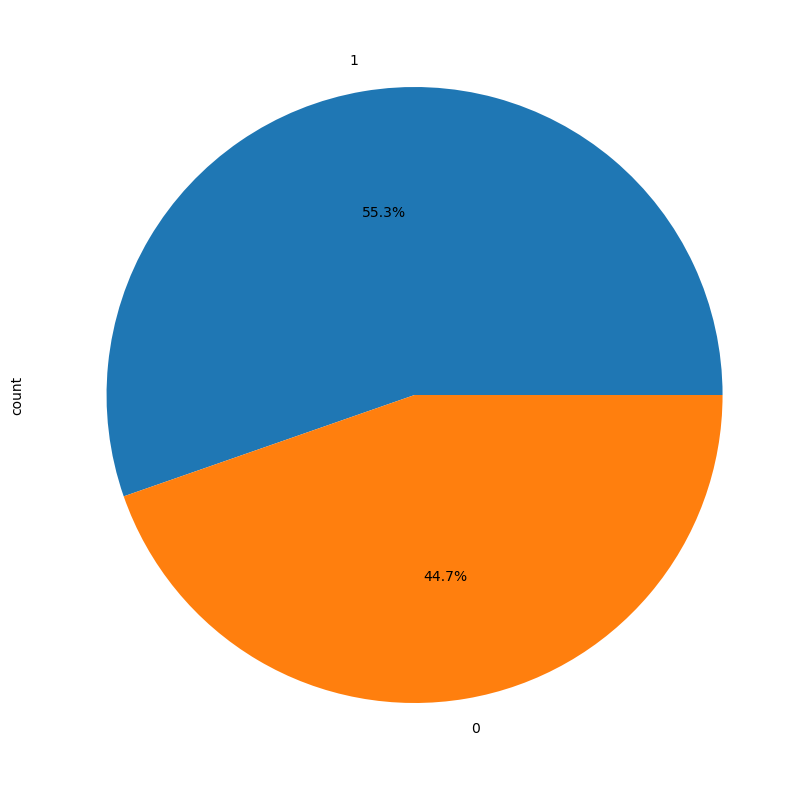

In [77]:
print(df["HeartDisease"].value_counts())
df["HeartDisease"].value_counts().plot(kind="pie", autopct='%1.1f%%', figsize=(10,10));

In [78]:
y = df['HeartDisease']
print(f'Percentage of Heart Disease: % {round(y.value_counts(normalize=True)[1]*100,2)} --> \
({y.value_counts()[1]} cases for Heart Disease)\nPercentage of NOT Heart Disease: % {round(y.value_counts(normalize=True)[0]*100,2)} --> ({y.value_counts()[0]} cases for NOT Heart Disease)')

Percentage of Heart Disease: % 55.34 --> (508 cases for Heart Disease)
Percentage of NOT Heart Disease: % 44.66 --> (410 cases for NOT Heart Disease)


In [79]:
df['HeartDisease'].describe()

count   918.000
mean      0.553
std       0.497
min       0.000
25%       0.000
50%       1.000
75%       1.000
max       1.000
Name: HeartDisease, dtype: float64

In [80]:
df[df['HeartDisease']==0].describe().T.style.background_gradient(subset=['mean','std','50%','count'], cmap='RdPu')

,count,mean,std,min,25%,50%,75%,max
Age,410.000000,50.551220,9.444915,28.000000,43.000000,51.000000,57.000000,76.000000
RestingBP,410.000000,130.180488,16.499585,80.000000,120.000000,130.000000,140.000000,190.000000
Cholesterol,410.000000,227.121951,74.634659,0.000000,197.250000,227.000000,266.750000,564.000000
FastingBS,410.000000,0.107317,0.309894,0.000000,0.000000,0.000000,0.000000,1.000000
MaxHR,410.000000,148.151220,23.288067,69.000000,134.000000,150.000000,165.000000,202.000000
Oldpeak,410.000000,0.408049,0.699709,-1.100000,0.000000,0.000000,0.600000,4.200000
HeartDisease,410.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [81]:

df[df['HeartDisease']==1].describe().T.style.background_gradient(subset=['mean','std','50%','count'], cmap='RdPu')

,count,mean,std,min,25%,50%,75%,max
Age,508.000000,55.899606,8.727056,31.000000,51.000000,57.000000,62.000000,77.000000
RestingBP,508.000000,134.185039,19.828685,0.000000,120.000000,132.000000,145.000000,200.000000
Cholesterol,508.000000,175.940945,126.391398,0.000000,0.000000,217.000000,267.000000,603.000000
FastingBS,508.000000,0.334646,0.472332,0.000000,0.000000,0.000000,1.000000,1.000000
MaxHR,508.000000,127.655512,23.386923,60.000000,112.000000,126.000000,144.250000,195.000000
Oldpeak,508.000000,1.274213,1.151872,-2.600000,0.000000,1.200000,2.000000,6.200000
HeartDisease,508.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [82]:
print( f"Skewness: {df['HeartDisease'].skew()}")

Skewness: -0.21508633825088655


In [83]:
print( f"Kurtosis: {df['HeartDisease'].kurtosis()}")

Kurtosis: -1.9580084425329685


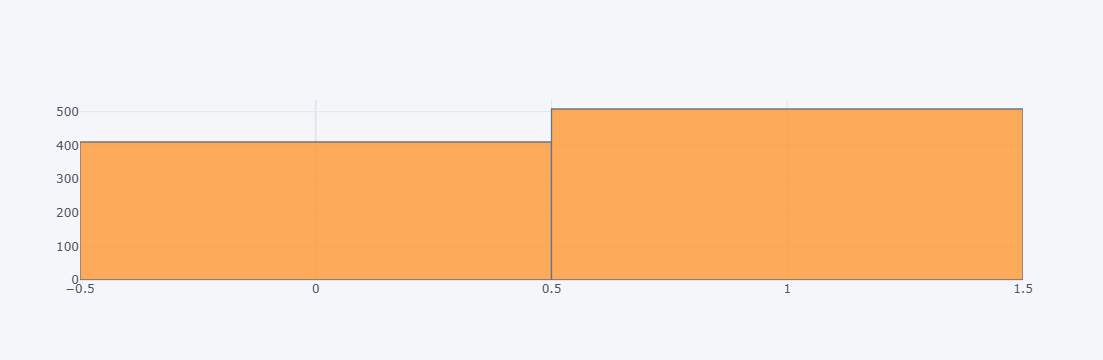

In [84]:
df['HeartDisease'].iplot(kind='hist')

In [85]:
numerical= df.drop(['HeartDisease'], axis=1).select_dtypes('number').columns

categorical = df.select_dtypes('object').columns

print(f'Numerical Columns:  {df[numerical].columns}')
print('\n')
print(f'Categorical Columns: {df[categorical].columns}')

Numerical Columns:  Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')


Categorical Columns: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [86]:
df[numerical].head().T

,0,1,2,3,4
Age,40.000,49.000,37.000,48.000,54.000
RestingBP,140.000,160.000,130.000,138.000,150.000
Cholesterol,289.000,180.000,283.000,214.000,195.000
FastingBS,0.000,0.000,0.000,0.000,0.000
MaxHR,172.000,156.000,98.000,108.000,122.000
Oldpeak,0.000,1.000,0.000,1.500,0.000


In [87]:
df[numerical].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.000,53.511,9.433,28.000,47.000,54.000,60.000,77.000
RestingBP,918.000,132.397,18.514,0.000,120.000,130.000,140.000,200.000
Cholesterol,918.000,198.800,109.384,0.000,173.250,223.000,267.000,603.000
FastingBS,918.000,0.233,0.423,0.000,0.000,0.000,0.000,1.000
MaxHR,918.000,136.809,25.460,60.000,120.000,138.000,156.000,202.000
Oldpeak,918.000,0.887,1.067,-2.600,0.000,0.600,1.500,6.200


In [88]:
df[numerical].describe().T.style.background_gradient(subset=['mean','std','50%','count'], cmap='RdPu')

,count,mean,std,min,25%,50%,75%,max
Age,918.000000,53.510893,9.432617,28.000000,47.000000,54.000000,60.000000,77.000000
RestingBP,918.000000,132.396514,18.514154,0.000000,120.000000,130.000000,140.000000,200.000000
Cholesterol,918.000000,198.799564,109.384145,0.000000,173.250000,223.000000,267.000000,603.000000
FastingBS,918.000000,0.233115,0.423046,0.000000,0.000000,0.000000,0.000000,1.000000
MaxHR,918.000000,136.809368,25.460334,60.000000,120.000000,138.000000,156.000000,202.000000
Oldpeak,918.000000,0.887364,1.066570,-2.600000,0.000000,0.600000,1.500000,6.200000


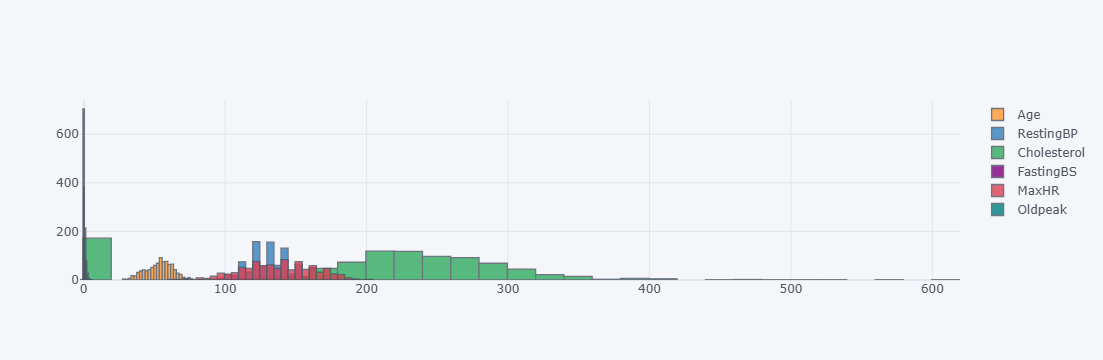

In [89]:
df[numerical].iplot(kind='hist');

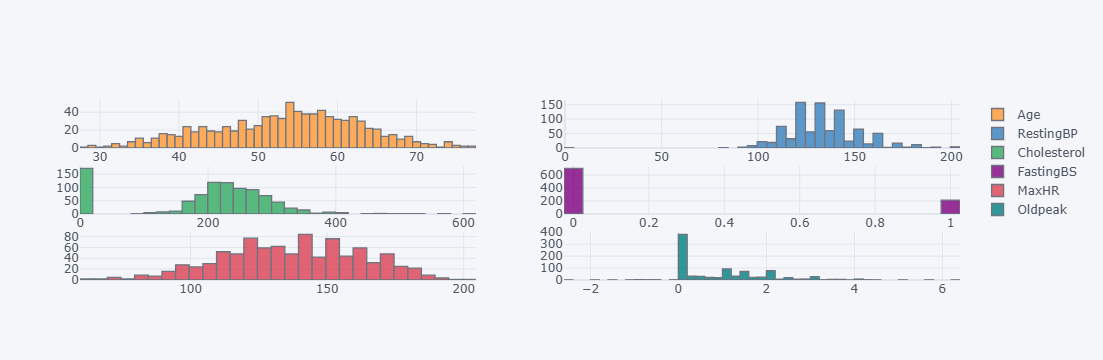

In [90]:
df[numerical].iplot(kind='histogram', subplots=True,bins=50)

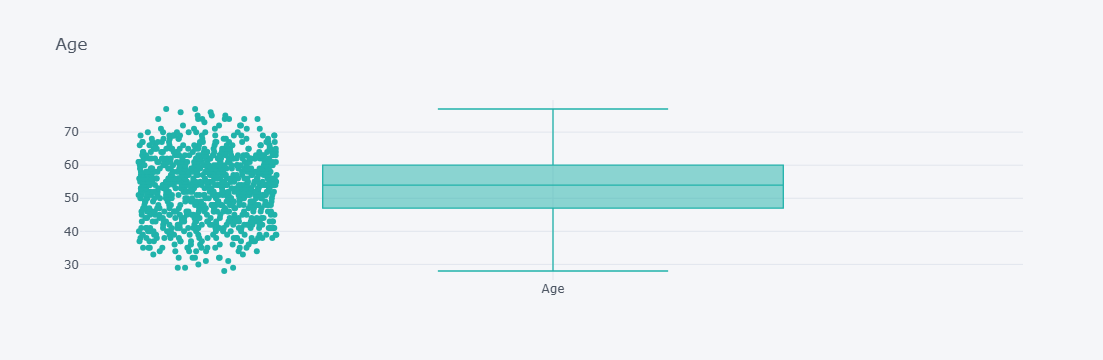

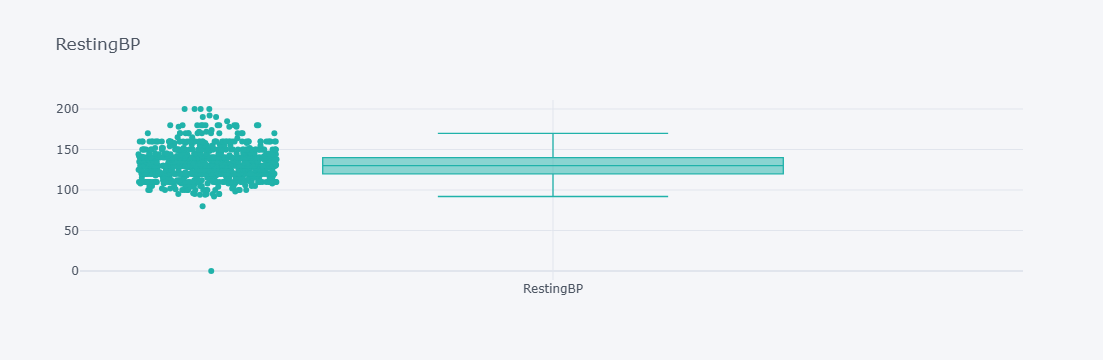

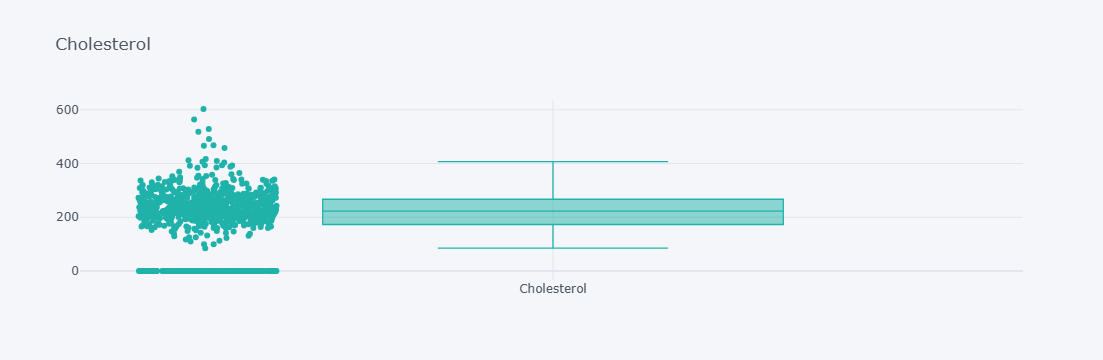

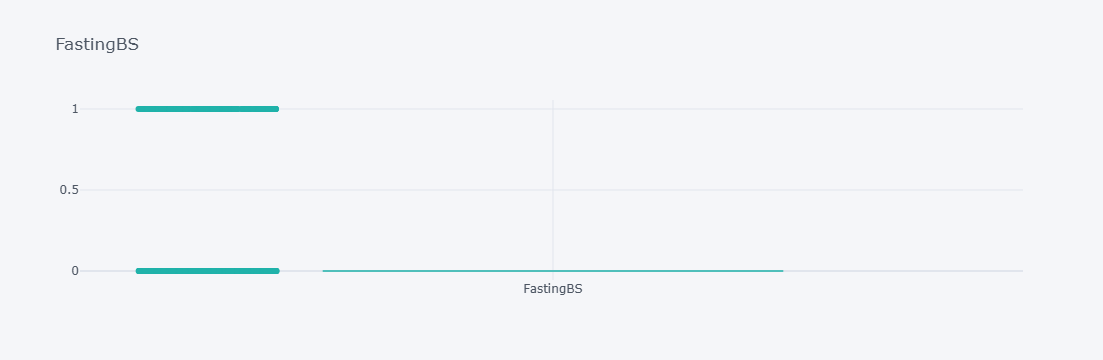

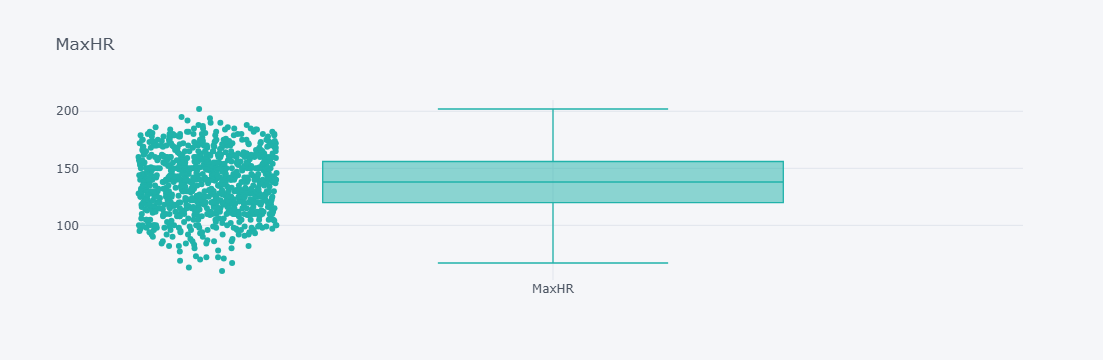

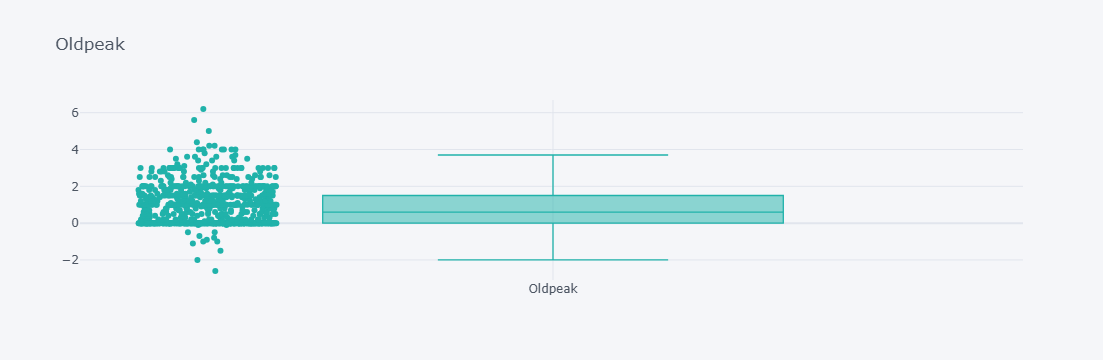

In [91]:
for i in numerical:
    df[i].iplot(kind="box", title=i, boxpoints="all", color='lightseagreen')

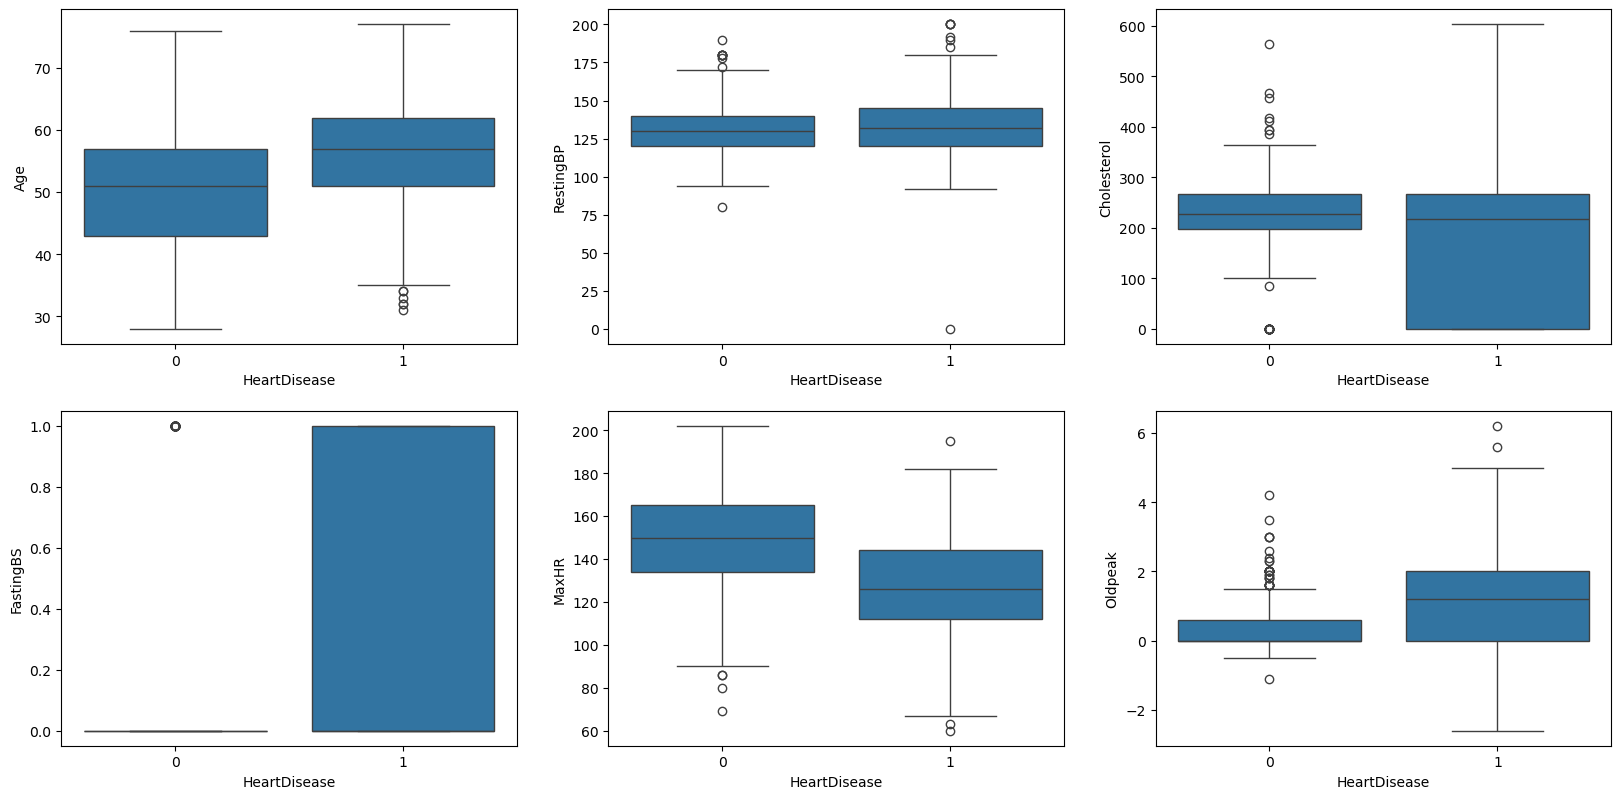

In [92]:
index = 0
plt.figure(figsize=(20,20))
for feature in numerical:
    if feature != "HeartDisease":
        index += 1
        plt.subplot(4, 3, index)
        sns.boxplot(x='HeartDisease', y=feature, data=df)

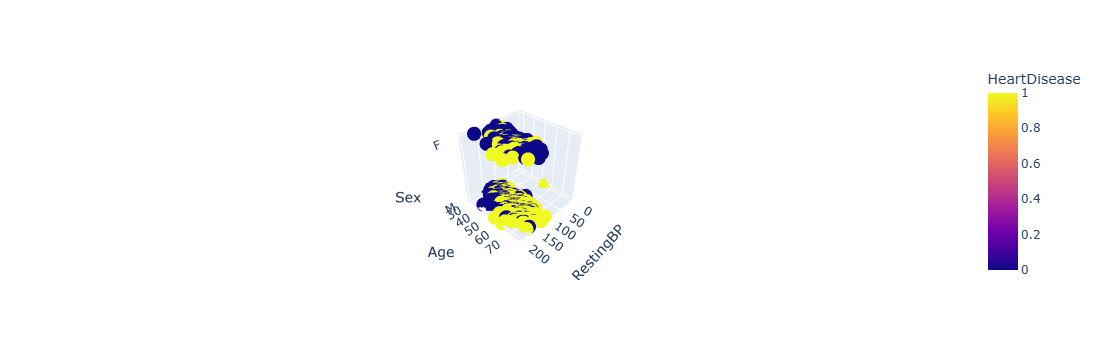

In [93]:
fig = px.scatter_3d(df, 
                    x='RestingBP',
                    y='Age',
                    z='Sex',
                    color='HeartDisease')
fig.show();

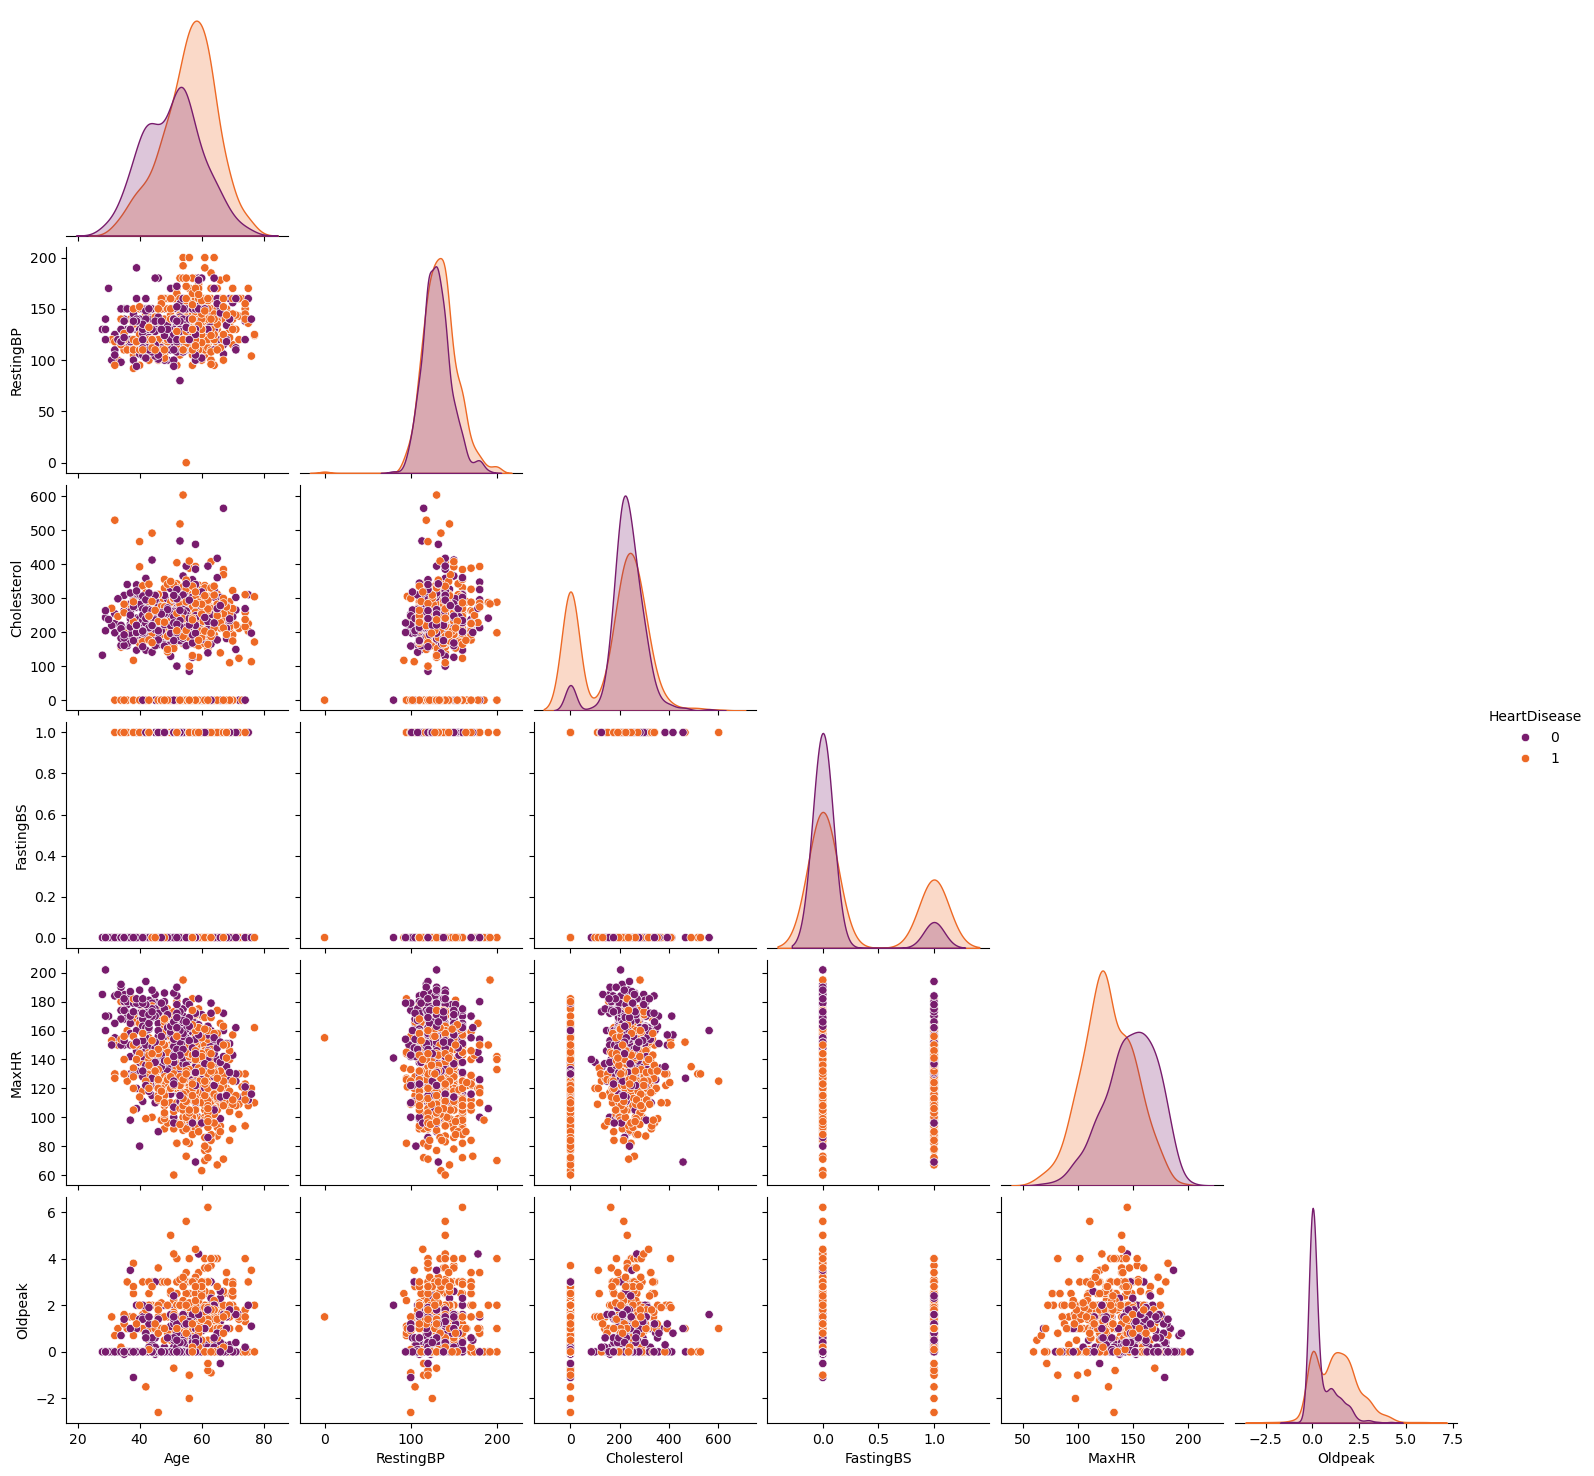

In [94]:
sns.pairplot(df, hue="HeartDisease", palette="inferno", corner=True);

In [103]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
skew_vals = numeric_df.skew().sort_values(ascending=False)
print(skew_vals)


FastingBS       1.264
Oldpeak         1.023
RestingBP       0.180
MaxHR          -0.144
Age            -0.196
HeartDisease   -0.215
Cholesterol    -0.610
dtype: float64


In [104]:
skew_limit = 0.5  
numeric_df = df.select_dtypes(include=['int64', 'float64'])
skew_vals = numeric_df.skew()
skew_cols = skew_vals[abs(skew_vals) > skew_limit].sort_values(ascending=False)

print(skew_cols)


FastingBS      1.264
Oldpeak        1.023
Cholesterol   -0.610
dtype: float64


In [105]:
#Interpreting Skewness 

for skew in skew_vals:
    if -0.5 < skew < 0.5:
        print ("A skewness value of", '\033[1m', Fore.GREEN, skew, '\033[0m', "means that the distribution is approx.", '\033[1m', Fore.GREEN, "symmetric", '\033[0m')
    elif  -0.5 < skew < -1.0 or 0.5 < skew < 1.0:
        print ("A skewness value of", '\033[1m', Fore.YELLOW, skew, '\033[0m', "means that the distribution is approx.", '\033[1m', Fore.YELLOW, "moderately skewed", '\033[0m')
    else:
        print ("A skewness value of", '\033[1m', Fore.RED, skew, '\033[0m', "means that the distribution is approx.", '\033[1m', Fore.RED, "highly skewed", '\033[0m')

A skewness value of   -0.19593302867569365  means that the distribution is approx.   symmetric 
A skewness value of   0.1798393100516288  means that the distribution is approx.   symmetric 
A skewness value of   -0.6100864307268192  means that the distribution is approx.   highly skewed 
A skewness value of   1.2644841750727027  means that the distribution is approx.   highly skewed 
A skewness value of   -0.14435941846180994  means that the distribution is approx.   symmetric 
A skewness value of   1.0228720218107528  means that the distribution is approx.   highly skewed 
A skewness value of   -0.21508633825088655  means that the distribution is approx.   symmetric 


In [107]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate kurtosis
kurtosis_vals = numeric_df.kurtosis().sort_values(ascending=False)
print(kurtosis_vals)


RestingBP       3.271
Oldpeak         1.203
Cholesterol     0.118
Age            -0.386
FastingBS      -0.402
MaxHR          -0.448
HeartDisease   -1.958
dtype: float64


In [109]:
# Threshold for kurtosis
kurtosis_limit = 7  

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate kurtosis and filter by threshold
kurtosis_vals = numeric_df.kurtosis()
kurtosis_cols = kurtosis_vals[abs(kurtosis_vals) > kurtosis_limit].sort_values(ascending=False)

print(kurtosis_cols)


Series([], dtype: float64)


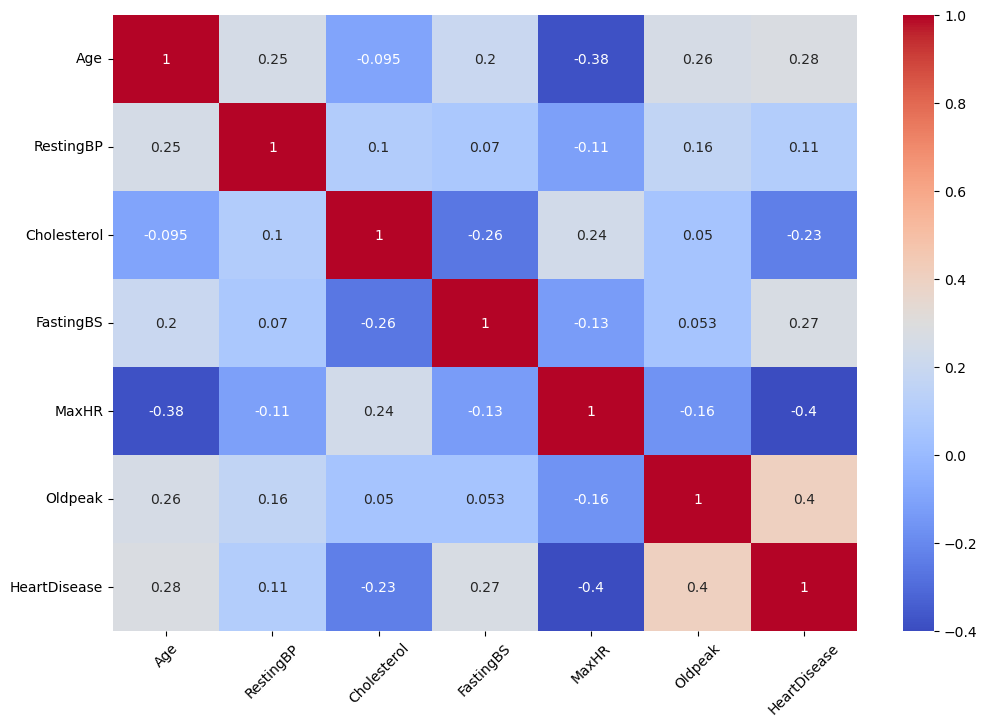

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


In [116]:
from colorama import Fore, init
init(autoreset=True)

numeric_df = df.select_dtypes(include=['int64','float64'])
df_temp = numeric_df.corr()

strong_corrs = []

for col in df_temp.columns:
    for i in df_temp.index:
        if (df_temp[col][i] > 0.9 and df_temp[col][i] < 1) or (df_temp[col][i] < -0.9 and df_temp[col][i] > -1):
            strong_corrs.append((col, i, df_temp[col][i]))
            print(Fore.RED + f"\033[1mMulticollinearity alert between\033[0m {col} - {i} : {df_temp[col][i]:.2f}")

print("\033[1mNumber of strong correlated feature pairs:\033[0m", len(strong_corrs))


Number of strong correlated feature pairs: 0


In [117]:
df[categorical].head().T

,0,1,2,3,4
Sex,M,F,M,F,M
ChestPainType,ATA,NAP,ATA,ASY,NAP
RestingECG,Normal,Normal,ST,Normal,Normal
ExerciseAngina,N,N,N,Y,N
ST_Slope,Up,Flat,Up,Flat,Up


In [118]:
df[categorical].describe()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


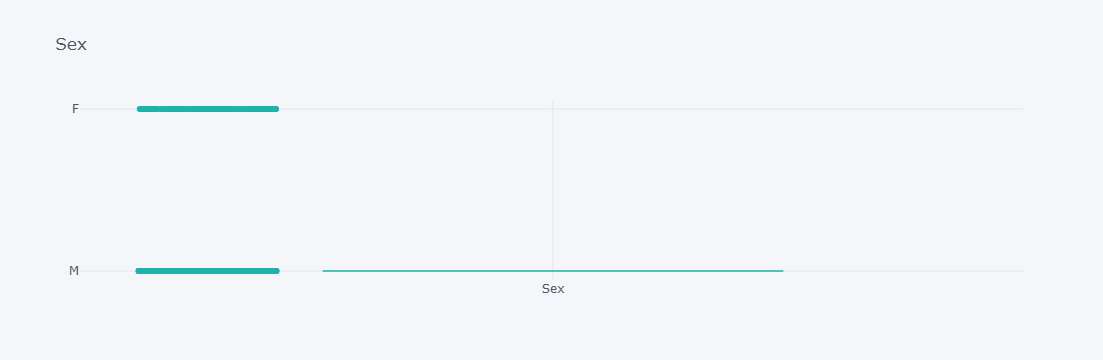

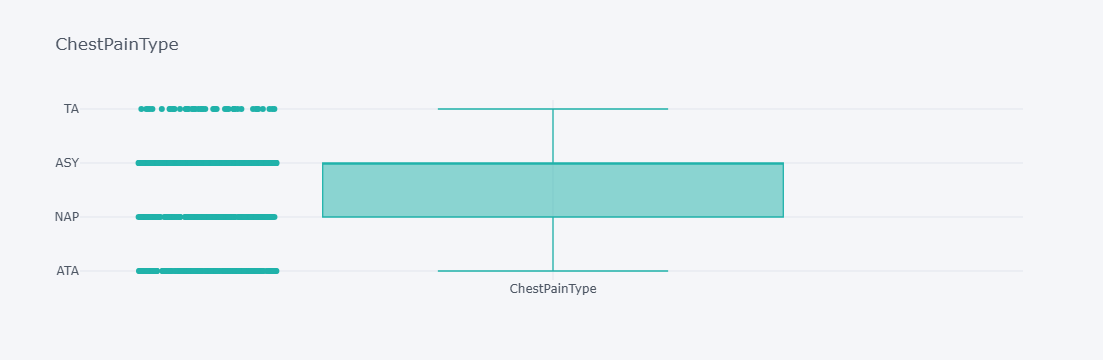

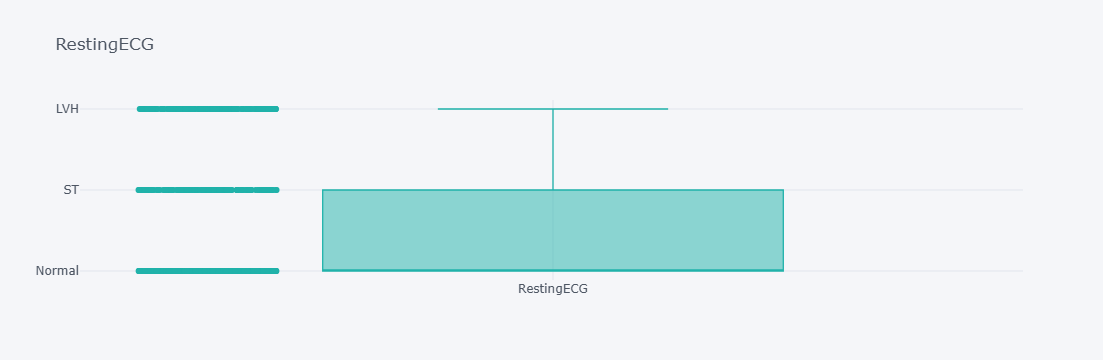

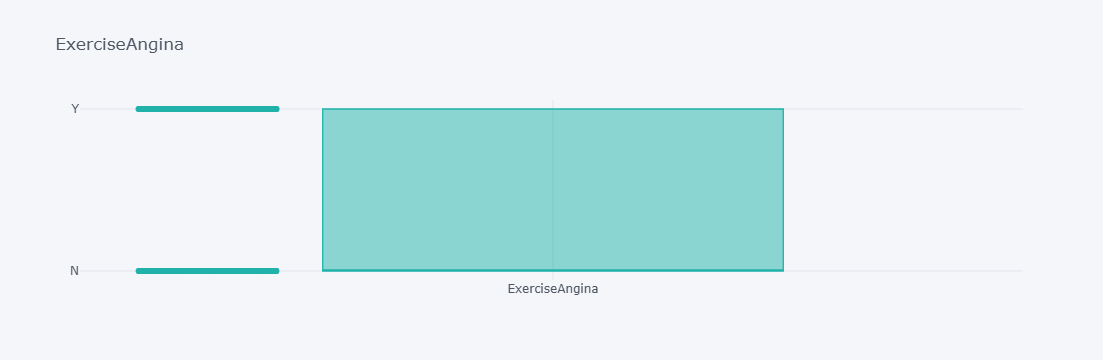

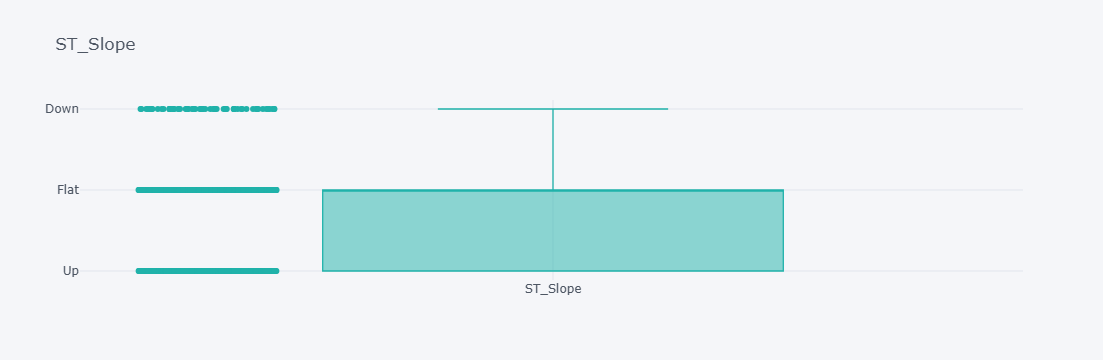

In [119]:
for i in categorical:
    df[i].iplot(kind="box", title=i, boxpoints="all", color='lightseagreen')

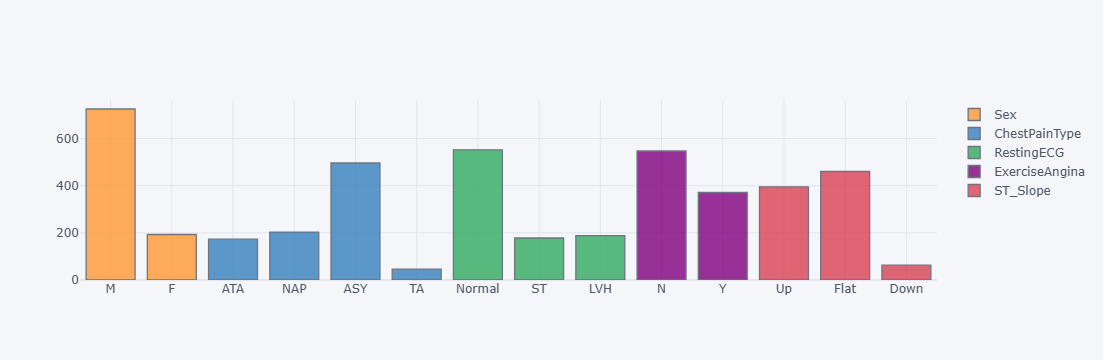

In [120]:
df[categorical].iplot(kind='hist');

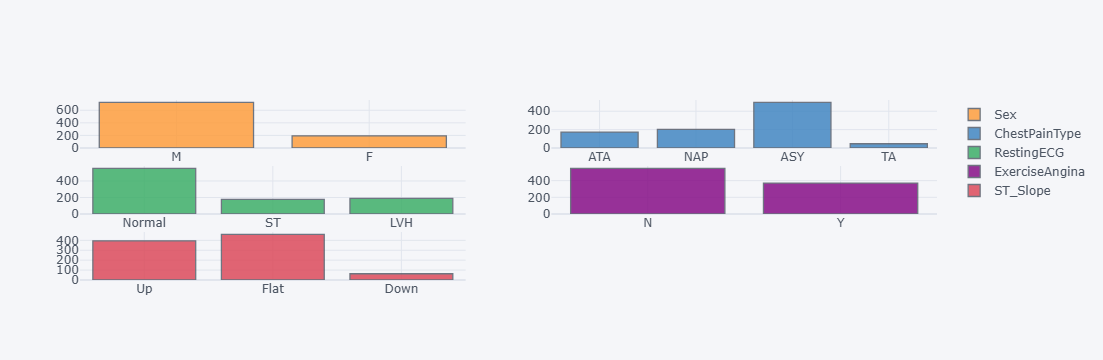

In [121]:
df[categorical].iplot(kind='histogram',subplots=True,bins=50)

In [122]:
df["Sex"].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

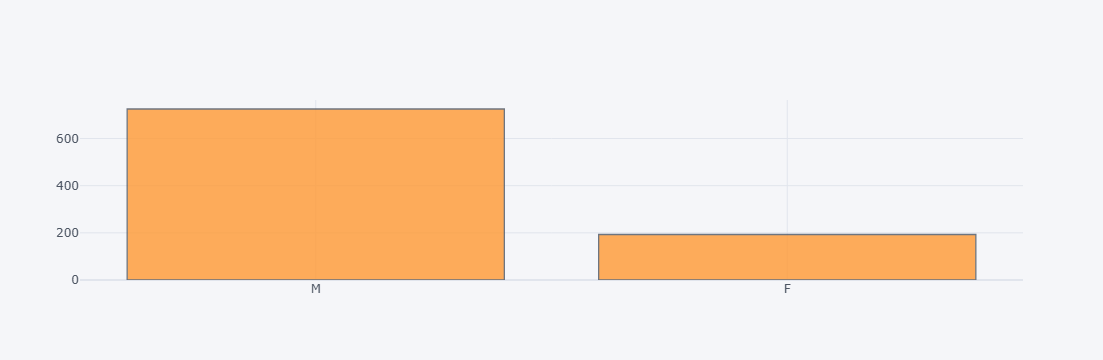

In [123]:
df['Sex'].iplot(kind='hist', )

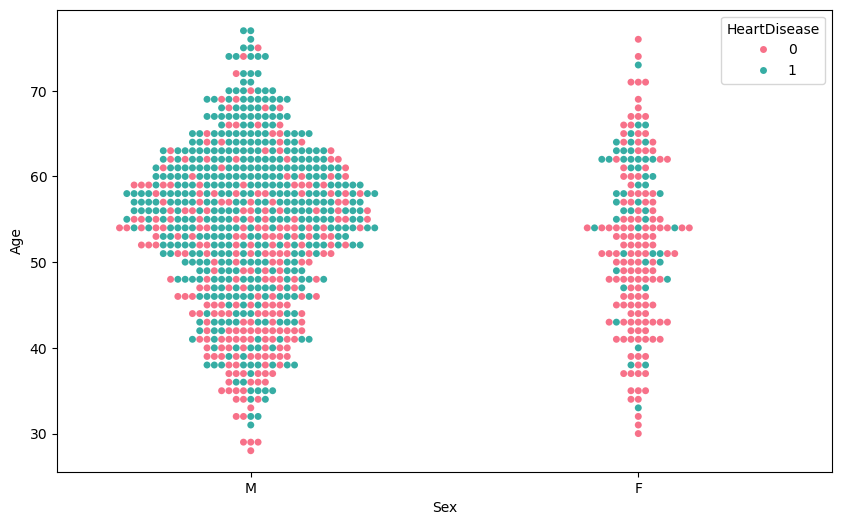

In [124]:
sns.swarmplot(y="Age", x="Sex", hue="HeartDisease", data=df, palette="husl");

In [125]:
df["ChestPainType"].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

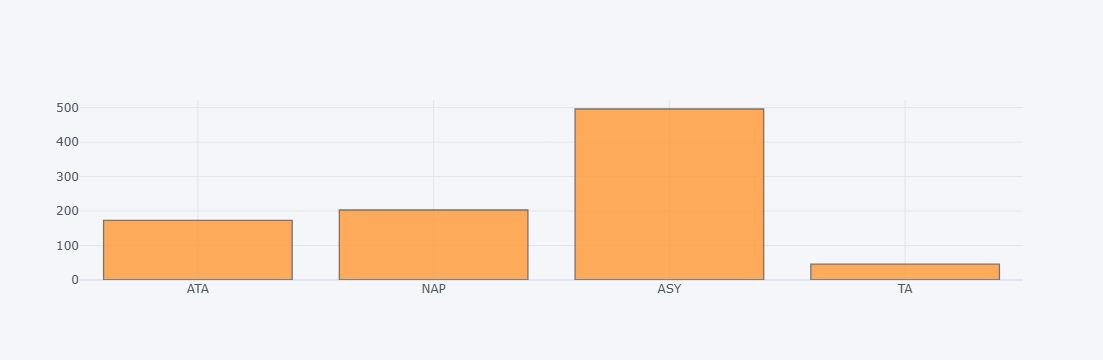

In [126]:
df['ChestPainType'].iplot(kind='hist', )

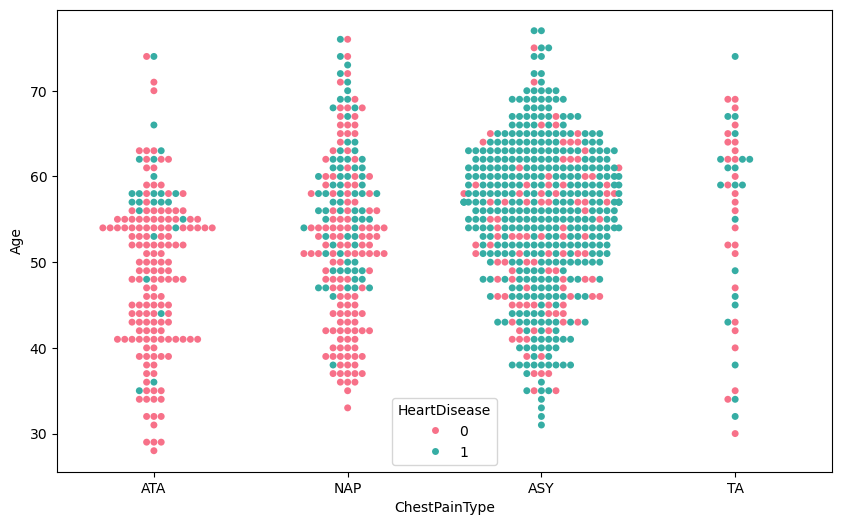

In [127]:
sns.swarmplot(y="Age", x="ChestPainType", hue="HeartDisease", data=df, palette="husl");

In [128]:
df["RestingECG"].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

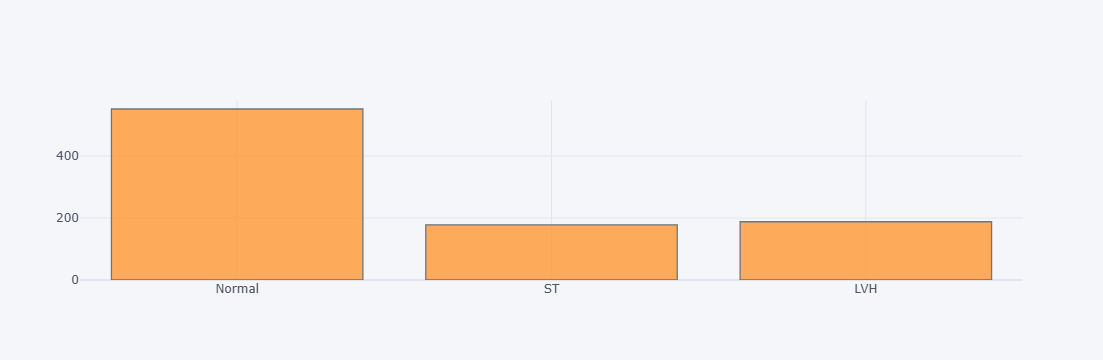

In [129]:
df['RestingECG'].iplot(kind='hist')

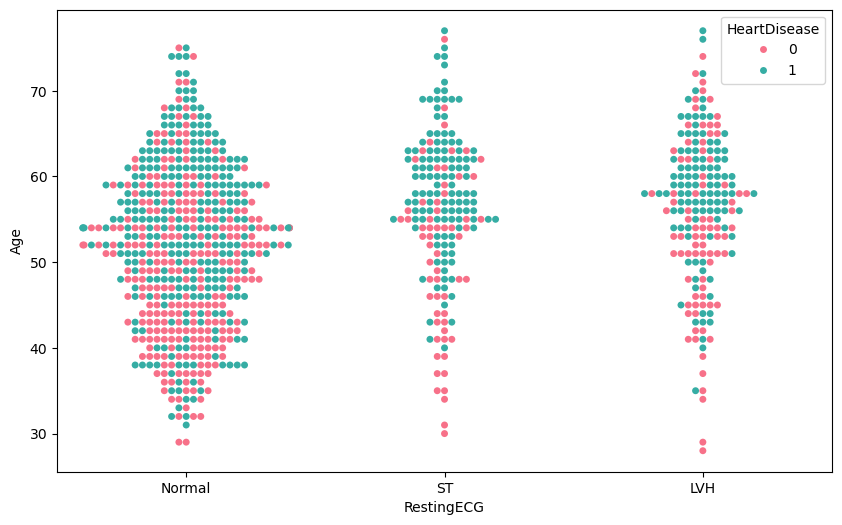

In [130]:
sns.swarmplot(y="Age", x="RestingECG", hue="HeartDisease", data=df, palette="husl");

In [131]:
df["ExerciseAngina"].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

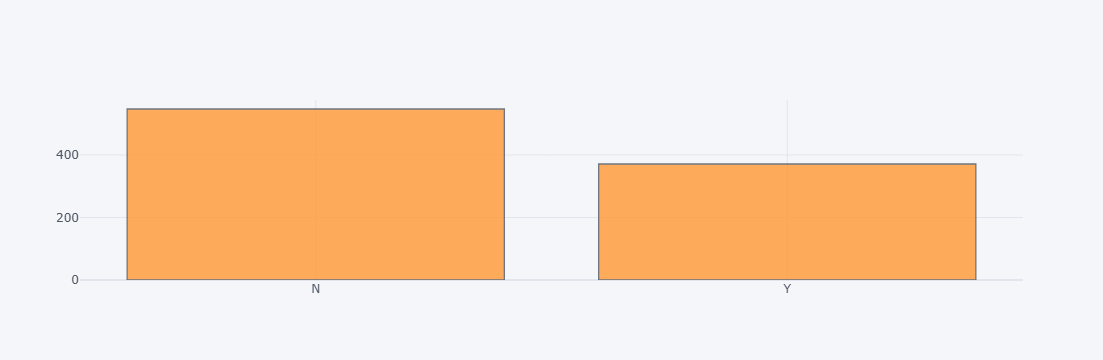

In [132]:
df['ExerciseAngina'].iplot(kind='hist')

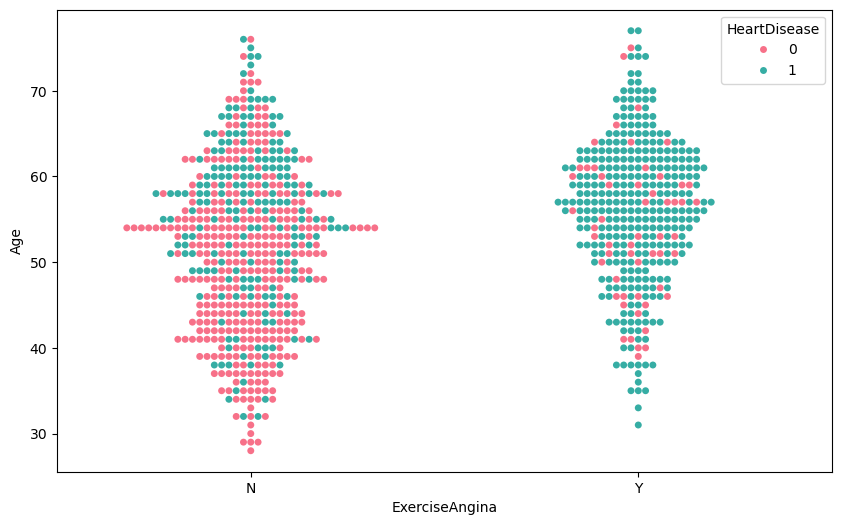

In [133]:
sns.swarmplot(y="Age", x="ExerciseAngina", hue="HeartDisease", data=df, palette="husl");

In [134]:
df["ST_Slope"].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

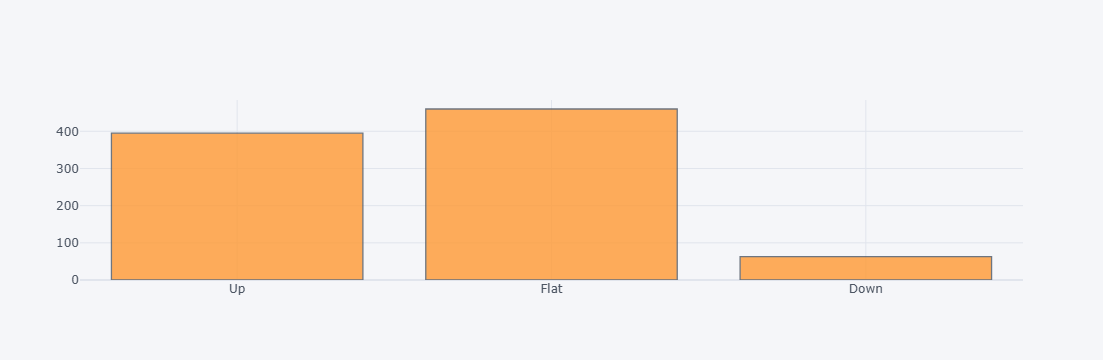

In [135]:
df['ST_Slope'].iplot(kind='hist')

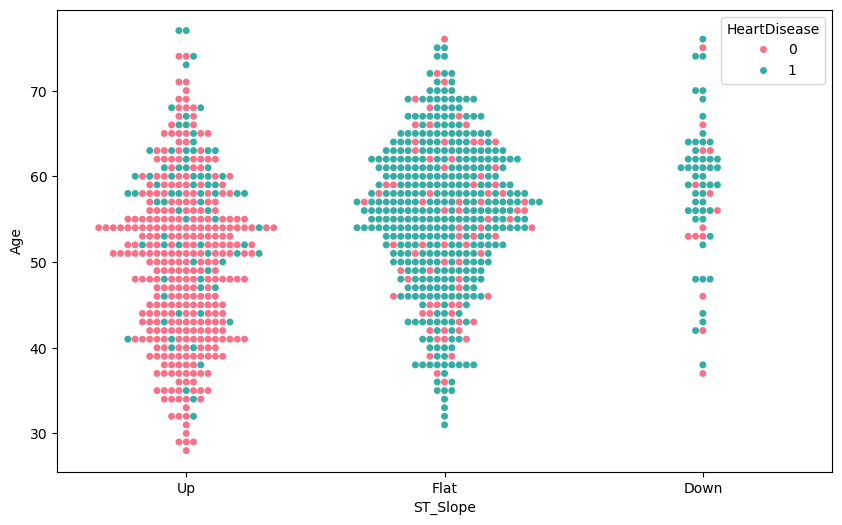

In [136]:
sns.swarmplot(y="Age", x="ST_Slope", hue="HeartDisease", data=df, palette="husl");

In [137]:
df.shape

(918, 12)

In [138]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.000,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.000,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.000,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.500,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.000,Up,0


In [139]:
df[categorical].value_counts()

Sex  ChestPainType  RestingECG  ExerciseAngina  ST_Slope
M    ASY            Normal      Y               Flat        109
     ATA            Normal      N               Up           64
     ASY            Normal      N               Flat         55
                    ST          Y               Flat         49
     NAP            Normal      N               Up           46
                                                           ... 
F    NAP            ST          Y               Flat          1
     TA             LVH         N               Up            1
                    Normal      N               Down          1
M    ATA            LVH         Y               Flat          1
     TA             ST          Y               Flat          1
Name: count, Length: 95, dtype: int64

In [140]:
df = pd.get_dummies(df, drop_first=True)

In [141]:
df.shape

(918, 16)

In [142]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.000,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.000,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.000,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.500,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.000,0,True,False,True,False,True,False,False,False,True


In [143]:
X = df.drop(["HeartDisease"], axis=1)
y = df["HeartDisease"]

In [144]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify = y, random_state = 101)

In [145]:
missing(df)

,Missing_Number,Missing_Percent
Age,0,0.000
RestingBP,0,0.000
Cholesterol,0,0.000
FastingBS,0,0.000
MaxHR,0,0.000
Oldpeak,0,0.000
HeartDisease,0,0.000
Sex_M,0,0.000
ChestPainType_ATA,0,0.000
ChestPainType_NAP,0,0.000


In [146]:
scaler = MinMaxScaler()
scaler

MinMaxScaler()

In [147]:
X_train_scaled = scaler.fit_transform(X_train)

In [148]:
X_test_scaled = scaler.transform(X_test)

In [154]:
# General Insights

def model_first_insight(X_train, y_train, class_weight, solver='liblinear'):
    # Logistic Regression
    log = LogisticRegression(random_state=101, class_weight=class_weight)
    log.fit(X_train, y_train)
    
    # Decision Tree
    decision_tree = DecisionTreeClassifier(criterion = 'entropy', random_state=101, class_weight=class_weight)
    decision_tree.fit(X_train, y_train)
   
    # Random Forest
    random_forest = RandomForestClassifier(n_estimators=10, criterion = 'entropy', random_state=101, class_weight=class_weight)
    random_forest.fit(X_train, y_train)
    
    # KNN
    knn = KNeighborsClassifier(n_neighbors = 3)
    knn.fit(X_train, y_train) 
   
    # SVC
    svc = SVC(random_state=101, class_weight=class_weight)
    svc.fit(X_train, y_train) 
    
    # XGB
    xgb = XGBClassifier(random_state=101, class_weight=class_weight)
    xgb.fit(X_train, y_train)
    
    # AdaBoosting
    ab = AdaBoostClassifier(n_estimators=50, random_state=101)
    ab.fit(X_train, y_train)
    
    # GB GradientBoosting
    gb = GradientBoostingClassifier(random_state=101)
    gb.fit(X_train, y_train)
    
    # Model Accuracy on Training Data
    print(f"\033[1m1) Logistic Regression Training Accuracy:\033[0m {log.score(X_train, y_train)}")
    print(f"\033[1m2) SVC Training Accuracy:\033[0m {svc.score(X_train, y_train)}")    
    print(f"\033[1m3) Decision Tree Training Accuracy:\033[0m {decision_tree.score(X_train, y_train)}")
    print(f"\033[1m4) Random Forest Training Accuracy:\033[0m {random_forest.score(X_train, y_train)}")
    print(f"\033[1m5) KNN Training Accuracy:\033[0m {knn.score(X_train, y_train)}")
    print(f"\033[1m6) GradiendBoosting Training Accuracy:\033[0m {gb.score(X_train, y_train)}")
    print(f"\033[1m7) AdaBoosting Training Accuracy:\033[0m {ab.score(X_train, y_train)}")
    print(f"\033[1m8) XGBoosting Training Accuracy:\033[0m {xgb.score(X_train, y_train)}")
    
    return log, svc, decision_tree, random_forest, knn, gb, ab, xgb

In [155]:
def models(X_train, y_train, class_weight):
    
    # Logistic Regression
    log = LogisticRegression(random_state=101, class_weight=class_weight, solver='liblinear')
    log.fit(X_train, y_train)
    
    # Decision Tree
    decision_tree = DecisionTreeClassifier(criterion = 'entropy', random_state=101, class_weight=class_weight)
    decision_tree.fit(X_train, y_train)
    
    # Random Forest
    random_forest = RandomForestClassifier(n_estimators=10, criterion = 'entropy', random_state=101, class_weight=class_weight)
    random_forest.fit(X_train, y_train)
    # KNN
    knn = KNeighborsClassifier(n_neighbors = 3)
    knn.fit(X_train, y_train) 
   
    # SVC
    svc = SVC(random_state=101, class_weight=class_weight)
    svc.fit(X_train, y_train) 
    
    # XGB
    xgb = XGBClassifier(random_state=101, class_weight=class_weight)
    xgb.fit(X_train, y_train)
    
    # AdaBoosting
    ab = AdaBoostClassifier(n_estimators=50, random_state=101)
    ab.fit(X_train, y_train)
    
    # GB GradientBoosting
    gb = GradientBoostingClassifier(random_state=101)
    gb.fit(X_train, y_train)
    
    # Model Accuracy on Training Data
    print(f"\033[1m1) Logistic Regression Training Accuracy:\033[0m {log}")
    print(f"\033[1m2) SVC Training Accuracy:\033[0m {svc}")    
    print(f"\033[1m3) Decision Tree Training Accuracy:\033[0m {decision_tree}")
    print(f"\033[1m4) Random Forest Training Accuracy:\033[0m {random_forest}")
    print(f"\033[1m5) KNN Training Accuracy:\033[0m {knn}")
    print(f"\033[1m6) GradiendBoosting Training Accuracy:\033[0m {gb}")
    print(f"\033[1m7) AdaBoosting Training Accuracy:\033[0m {ab}")
    print(f"\033[1m8) XGBoosting Training Accuracy:\033[0m {xgb}")
  
    return log.score(X_train, y_train), svc.score(X_train, y_train),decision_tree.score(X_train, y_train),random_forest.score(X_train, y_train),knn.score(X_train, y_train),gb.score(X_train, y_train),ab.score(X_train, y_train),xgb.score(X_train, y_train)

In [156]:
def models_accuracy(X_Set, y_Set):    
    Scores = pd.DataFrame(columns = ["LR_Acc", "SVC_Acc", "DT_Acc", "RF_Acc", "KNN_Acc", "GB_Acc", "AB_Acc", "XGB_Acc"])

    print("\033[1mBASIC ACCURACY\033[0m")
    Basic = [log_acc, svc_acc, decision_tree_acc, random_forest_acc, knn_acc, gb_acc, ab_acc, xgb_acc] = models(X_train, y_train, None)
    Scores.loc[0] = Basic

    print("\n\033[1mSCALED ACCURACY WITHOUT BALANCED\033[0m")    
    Scaled = [log_acc, svc_acc, decision_tree_acc, random_forest_acc, knn_acc, gb_acc, ab_acc, xgb_acc] = models(X_train_scaled, y_train, None)
    Scores.loc[1] = Scaled

    
    print("\n\033[1mBASIC ACCURACY WITH BALANCED\033[0m")
    Balanced = [log_acc, svc_acc, decision_tree_acc, random_forest_acc, knn_acc, gb_acc, ab_acc, xgb_acc] = models(X_train, y_train, "balanced")
    Scores.loc[2] = Balanced

    print("\n\033[1mSCALED ACCURACY WITH BALANCED\033[0m")    
    Scaled_Balanced = [log_acc, svc_acc, decision_tree_acc, random_forest_acc, knn_acc, gb_acc, ab_acc, xgb_acc] = models(X_train_scaled, y_train, "balanced")
    Scores.loc[3] = Scaled_Balanced

    Scores.set_axis(['Basic', 'Scaled', 'Balanced', 'Scaled_Balanced'], axis='index', inplace=True)
    #Scores.style.background_gradient(cmap='RdPu')

    return Scores.style.applymap(lambda x: "background-color: pink" if x<0.6 or x == 1 else "background-color: lightgreen")\
                       .applymap(lambda x: 'opacity: 40%;' if (x < 0.8) else None)\
                       .applymap(lambda x: 'color: red' if x == 1 or x <=0.8 else 'color: darkblue')

# https://pandas.pydata.org/pandas-docs/stable/user_guide/style.html

In [159]:
def models_accuracy(X_Set, y_Set):
    # Basic Accuracy
    Basic = models(X_Set, y_Set, class_weight=None)
    
    # Scaled Accuracy
    Scaled = models(X_train_scaled, y_train, class_weight=None)
    
    # Basic Accuracy with Balanced
    Balanced = models(X_Set, y_Set, class_weight='balanced')
    
    # Scaled Accuracy with Balanced
    Scaled_Balanced = models(X_train_scaled, y_train, class_weight='balanced')
    
    # Create DataFrame
    Scores = pd.DataFrame([Basic, Scaled, Balanced, Scaled_Balanced],
                          columns=['Logistic', 'SVC', 'DecisionTree', 'RandomForest',
                                   'KNN', 'GradientBoosting', 'AdaBoost', 'XGBoost'])
    
    Scores.index = ['Basic', 'Scaled', 'Balanced', 'Scaled_Balanced']
    
    # Styling the dataframe
    styled_scores = Scores.style.applymap(
        lambda x: "background-color: pink" if x < 0.6 or x == 1 else "background-color: lightgreen"
    ).applymap(
        lambda x: 'opacity: 40%;' if x < 0.8 else None
    ).applymap(
        lambda x: 'color: red' if x == 1 or x <= 0.8 else 'color: darkblue'
    )
    
    return styled_scores


In [160]:
models_accuracy(X_train, y_train)

1) Logistic Regression Training Accuracy: LogisticRegression(random_state=101, solver='liblinear')
2) SVC Training Accuracy: SVC(random_state=101)
3) Decision Tree Training Accuracy: DecisionTreeClassifier(criterion='entropy', random_state=101)
4) Random Forest Training Accuracy: RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=101)
5) KNN Training Accuracy: KNeighborsClassifier(n_neighbors=3)
6) GradiendBoosting Training Accuracy: GradientBoostingClassifier(random_state=101)
7) AdaBoosting Training Accuracy: AdaBoostClassifier(random_state=101)
8) XGBoosting Training Accuracy: XGBClassifier(base_score=None, booster=None, callbacks=None, class_weight=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_ty

,Logistic,SVC,DecisionTree,RandomForest,KNN,GradientBoosting,AdaBoost,XGBoost
Basic,0.870513,0.728205,1.000000,0.989744,0.833333,0.939744,0.879487,1.000000
Scaled,0.861538,0.883333,1.000000,0.989744,0.910256,0.939744,0.879487,1.000000
Balanced,0.866667,0.714103,1.000000,0.997436,0.833333,0.939744,0.879487,1.000000
Scaled_Balanced,0.866667,0.883333,1.000000,0.997436,0.910256,0.939744,0.879487,1.000000


In [162]:
scenarios = [
    ("Basic", X_train, None),
    ("Scaled", X_train_scaled, None),
    ("Balanced", X_train, "balanced"),
    ("Scaled_Balanced", X_train_scaled, "balanced")
]

Scores = pd.DataFrame(columns=["LR_Acc","SVC_Acc","DT_Acc","RF_Acc","KNN_Acc","GB_Acc","AB_Acc","XGB_Acc"])

for i, (name, X_set, weight) in enumerate(scenarios):
    print(f"\n\033[1m{name.upper()} ACCURACY\033[0m")
    accs = models(X_set, y_train, weight)  # returns 8 accuracies
    Scores.loc[i] = accs

Scores.index = [name for name, _, _ in scenarios]



BASIC ACCURACY
1) Logistic Regression Training Accuracy: LogisticRegression(random_state=101, solver='liblinear')
2) SVC Training Accuracy: SVC(random_state=101)
3) Decision Tree Training Accuracy: DecisionTreeClassifier(criterion='entropy', random_state=101)
4) Random Forest Training Accuracy: RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=101)
5) KNN Training Accuracy: KNeighborsClassifier(n_neighbors=3)
6) GradiendBoosting Training Accuracy: GradientBoostingClassifier(random_state=101)
7) AdaBoosting Training Accuracy: AdaBoostClassifier(random_state=101)
8) XGBoosting Training Accuracy: XGBClassifier(base_score=None, booster=None, callbacks=None, class_weight=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
           

In [163]:
accuracy_scores = Scores.style.applymap(lambda x: "background-color: pink" if x<0.6 or x == 1 else "background-color: lightgreen")\
                              .applymap(lambda x: 'opacity: 40%;' if (x < 0.8) else None)\
                              .applymap(lambda x: 'color: red' if x == 1 or x <=0.8 else 'color: darkblue')

accuracy_scores

,LR_Acc,SVC_Acc,DT_Acc,RF_Acc,KNN_Acc,GB_Acc,AB_Acc,XGB_Acc
Basic,0.870513,0.728205,1.000000,0.989744,0.833333,0.939744,0.879487,1.000000
Scaled,0.861538,0.883333,1.000000,0.989744,0.910256,0.939744,0.879487,1.000000
Balanced,0.866667,0.714103,1.000000,0.997436,0.833333,0.939744,0.879487,1.000000
Scaled_Balanced,0.866667,0.883333,1.000000,0.997436,0.910256,0.939744,0.879487,1.000000


In [164]:
accuracy_scores

,LR_Acc,SVC_Acc,DT_Acc,RF_Acc,KNN_Acc,GB_Acc,AB_Acc,XGB_Acc
Basic,0.870513,0.728205,1.000000,0.989744,0.833333,0.939744,0.879487,1.000000
Scaled,0.861538,0.883333,1.000000,0.989744,0.910256,0.939744,0.879487,1.000000
Balanced,0.866667,0.714103,1.000000,0.997436,0.833333,0.939744,0.879487,1.000000
Scaled_Balanced,0.866667,0.883333,1.000000,0.997436,0.910256,0.939744,0.879487,1.000000


In [165]:
operations = [("scaler", MinMaxScaler()), ("power", PowerTransformer()), ("log", LogisticRegression(random_state=101))]

In [166]:
# Defining the pipeline object for LogisticClassifier

pipe_log_model = Pipeline(steps=operations)

In [167]:
# Another step by step way for defining the pipeline object for LogisticClassifier

# scaler = MinMaxScaler()
# power = PowerTransformer(method='yeo-johnson')
# pipe_model = LogisticRegression(random_state=101)
# pipe_log_model = Pipeline(steps=[('s', scaler),('p', power), ('m', pipe_model)])

In [168]:
pipe_log_model.get_params()

{'memory': None,
 'steps': [('scaler', MinMaxScaler()),
  ('power', PowerTransformer()),
  ('log', LogisticRegression(random_state=101))],
 'verbose': False,
 'scaler': MinMaxScaler(),
 'power': PowerTransformer(),
 'log': LogisticRegression(random_state=101),
 'scaler__clip': False,
 'scaler__copy': True,
 'scaler__feature_range': (0, 1),
 'power__copy': True,
 'power__method': 'yeo-johnson',
 'power__standardize': True,
 'log__C': 1.0,
 'log__class_weight': None,
 'log__dual': False,
 'log__fit_intercept': True,
 'log__intercept_scaling': 1,
 'log__l1_ratio': None,
 'log__max_iter': 100,
 'log__multi_class': 'deprecated',
 'log__n_jobs': None,
 'log__penalty': 'l2',
 'log__random_state': 101,
 'log__solver': 'lbfgs',
 'log__tol': 0.0001,
 'log__verbose': 0,
 'log__warm_start': False}

In [169]:
pipe_log_model.fit(X_train, y_train)
y_pred = pipe_log_model.predict(X_test)
y_train_pred = pipe_log_model.predict(X_train)

In [170]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[52 10]
 [ 7 69]]
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        62
           1       0.87      0.91      0.89        76

    accuracy                           0.88       138
   macro avg       0.88      0.87      0.87       138
weighted avg       0.88      0.88      0.88       138



In [171]:
pipe_scores = cross_validate(pipe_log_model, X_train, y_train, scoring = ['accuracy', 'precision','recall','f1'], cv = 10)
df_pipe_scores = pd.DataFrame(pipe_scores, index = range(1, 11))

df_pipe_scores

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
1,0.054,0.020,0.795,0.787,0.860,0.822
2,0.099,0.024,0.821,0.822,0.860,0.841
3,0.088,0.014,0.885,0.886,0.907,0.897
4,0.098,0.025,0.833,0.875,0.814,0.843
5,0.086,0.019,0.897,0.889,0.930,0.909
6,0.098,0.021,0.821,0.822,0.860,0.841
7,0.097,0.018,0.872,0.851,0.930,0.889
8,0.113,0.020,0.833,0.826,0.884,0.854
9,0.110,0.024,0.833,0.878,0.818,0.847
10,0.086,0.022,0.923,0.913,0.955,0.933


In [172]:
df_pipe_scores.mean()[2:]

test_accuracy    0.851
test_precision   0.855
test_recall      0.882
test_f1          0.868
dtype: float64

In [173]:
# evaluate the pipeline

# from sklearn.model_selection import RepeatedStratifiedKFold

cv = RepeatedStratifiedKFold(n_splits=10, random_state=101)
n_scores = cross_val_score(pipe_log_model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')

print(f'Accuracy: Results Mean : %{round(n_scores.mean()*100,3)}, Results Standard Deviation : {round(n_scores.std()*100,3)}')

Accuracy: Results Mean : %85.739, Results Standard Deviation : 3.226


In [174]:
print('Accuracy: %.3f (%.3f)' % (n_scores.mean(), n_scores.std()))

Accuracy: 0.857 (0.032)


In [175]:
accuracy_scores

,LR_Acc,SVC_Acc,DT_Acc,RF_Acc,KNN_Acc,GB_Acc,AB_Acc,XGB_Acc
Basic,0.870513,0.728205,1.000000,0.989744,0.833333,0.939744,0.879487,1.000000
Scaled,0.861538,0.883333,1.000000,0.989744,0.910256,0.939744,0.879487,1.000000
Balanced,0.866667,0.714103,1.000000,0.997436,0.833333,0.939744,0.879487,1.000000
Scaled_Balanced,0.866667,0.883333,1.000000,0.997436,0.910256,0.939744,0.879487,1.000000


[[67 10]
 [17 90]]
--------------------------------------------------------
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184

--------------------------------------------------------


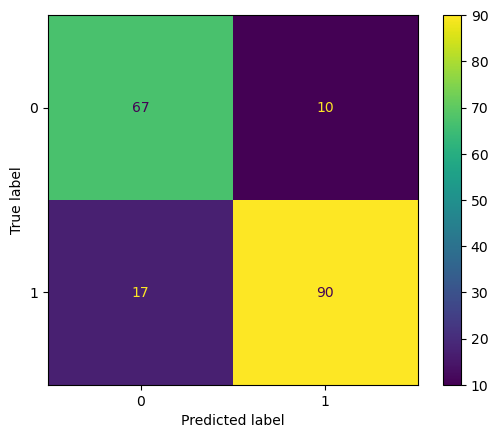

           train_set  test_set
Accuracy       0.872     0.853
Precision      0.872     0.900
Recall         0.898     0.841
f1             0.885     0.870


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1️⃣ Load dataset
df = pd.read_csv("C:/Users/akeem/Downloads/heart.csv")

# 2️⃣ Define features and target
TARGET_COLUMN = "HeartDisease"
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

# 3️⃣ Convert categorical columns to numeric using one-hot encoding
X = pd.get_dummies(X, drop_first=True)  # drop_first=True to avoid dummy variable trap

# 4️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5️⃣ Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6️⃣ Train Logistic Regression
LR_model = LogisticRegression(solver='liblinear', random_state=42)
LR_model.fit(X_train_scaled, y_train)

# 7️⃣ Predictions
y_train_pred = LR_model.predict(X_train_scaled)
y_test_pred = LR_model.predict(X_test_scaled)

# 8️⃣ Evaluation
print(confusion_matrix(y_test, y_test_pred))
print("\033[1m--------------------------------------------------------\033[0m")
print(classification_report(y_test, y_test_pred))
print("\033[1m--------------------------------------------------------\033[0m")

# 9️⃣ Confusion Matrix Plot
ConfusionMatrixDisplay.from_estimator(LR_model, X_test_scaled, y_test)
plt.show()

# 🔟 Train vs Test Metrics Table
metrics = {
    "train_set": {
        "Accuracy": round(accuracy_score(y_train, y_train_pred), 3),
        "Precision": round(precision_score(y_train, y_train_pred), 3),
        "Recall": round(recall_score(y_train, y_train_pred), 3),
        "f1": round(f1_score(y_train, y_train_pred), 3)
    },
    "test_set": {
        "Accuracy": round(accuracy_score(y_test, y_test_pred), 3),
        "Precision": round(precision_score(y_test, y_test_pred), 3),
        "Recall": round(recall_score(y_test, y_test_pred), 3),
        "f1": round(f1_score(y_test, y_test_pred), 3)
    }
}

metrics_df = pd.DataFrame(metrics)
print(metrics_df)


In [18]:
y_pred_proba = LR_model.predict_proba(X_test_scaled)
y_pred_proba

array([[0.98096973, 0.01903027],
       [0.85492969, 0.14507031],
       [0.02224451, 0.97775549],
       [0.01742012, 0.98257988],
       [0.96439421, 0.03560579],
       [0.10355767, 0.89644233],
       [0.12852002, 0.87147998],
       [0.9174817 , 0.0825183 ],
       [0.19543306, 0.80456694],
       [0.04641251, 0.95358749],
       [0.2484712 , 0.7515288 ],
       [0.90721386, 0.09278614],
       [0.36573993, 0.63426007],
       [0.93234934, 0.06765066],
       [0.06682564, 0.93317436],
       [0.2394581 , 0.7605419 ],
       [0.98611864, 0.01388136],
       [0.11711076, 0.88288924],
       [0.19441018, 0.80558982],
       [0.91077192, 0.08922808],
       [0.17670201, 0.82329799],
       [0.21083776, 0.78916224],
       [0.96828129, 0.03171871],
       [0.26049911, 0.73950089],
       [0.16888596, 0.83111404],
       [0.09046537, 0.90953463],
       [0.95507027, 0.04492973],
       [0.16931978, 0.83068022],
       [0.94758475, 0.05241525],
       [0.96545139, 0.03454861],
       [0.

In [20]:
# 1️⃣ Predictions
y_pred = LR_model.predict(X_test_scaled)
y_pred_proba = LR_model.predict_proba(X_test_scaled)  # probabilities for both classes

# 2️⃣ Combine with test data
test_data = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)
test_data["pred"] = y_pred
test_data["pred_proba"] = y_pred_proba[:, 1]  # probability of class 1

# 3️⃣ Sample 10 rows
test_data.sample(10)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,HeartDisease,pred,pred_proba
107,51,130,0,1,170,-0.7,True,False,False,False,True,False,False,False,True,1,1,0.574676
28,44,130,219,0,188,0.0,True,True,False,False,False,False,False,False,True,0,0,0.052415
122,32,95,0,1,127,0.7,True,False,False,True,True,False,False,False,True,1,0,0.407784
120,61,146,241,0,148,3.0,True,False,False,False,True,False,True,False,False,1,1,0.904527
119,52,118,186,0,190,0.0,True,False,False,True,False,False,False,True,False,0,1,0.527132
33,43,150,247,0,130,2.0,True,False,False,False,True,False,True,True,False,1,1,0.947431
44,60,120,178,1,96,0.0,False,False,True,False,True,False,False,False,True,0,0,0.067310
128,42,134,240,0,160,0.0,True,False,True,False,True,False,False,False,True,0,0,0.040868
132,48,106,263,1,110,0.0,True,False,False,False,True,False,False,True,False,1,1,0.872236
65,51,128,0,1,125,1.2,True,False,False,False,False,True,True,True,False,1,1,0.989994


In [22]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
import pandas as pd

# 1️⃣ Initialize model
log_xvalid_model = LogisticRegression(solver='liblinear', random_state=42)

# 2️⃣ Cross-validation on training set
log_xvalid_model_scores = cross_validate(
    log_xvalid_model, 
    X_train_scaled, 
    y_train, 
    scoring=['accuracy', 'precision', 'recall', 'f1'], 
    cv=10,
    return_train_score=False
)

# 3️⃣ Convert to DataFrame
log_xvalid_model_scores_df = pd.DataFrame(log_xvalid_model_scores)
log_xvalid_model_scores_df.index = range(1, len(log_xvalid_model_scores_df)+1)  # Fold numbers 1-10

# 4️⃣ Show CV scores
print(log_xvalid_model_scores_df)


    fit_time  score_time  test_accuracy  test_precision  test_recall   test_f1
1   0.000000    0.010461       0.918919        0.925000     0.925000  0.925000
2   0.003636    0.001100       0.878378        0.897436     0.875000  0.886076
3   0.008336    0.015905       0.891892        0.921053     0.875000  0.897436
4   0.008088    0.016109       0.864865        0.860465     0.902439  0.880952
5   0.003651    0.014864       0.821918        0.813953     0.875000  0.843373
6   0.000000    0.030045       0.876712        0.878049     0.900000  0.888889
7   0.007339    0.016173       0.794521        0.790698     0.850000  0.819277
8   0.010273    0.017806       0.876712        0.878049     0.900000  0.888889
9   0.006241    0.022912       0.904110        0.883721     0.950000  0.915663
10  0.000000    0.024734       0.835616        0.818182     0.900000  0.857143


In [24]:
cv_mean_scores = log_xvalid_model_scores_df[['test_accuracy', 'test_precision', 'test_recall', 'test_f1']].mean()
print(cv_mean_scores)


test_accuracy     0.866364
test_precision    0.866661
test_recall       0.895244
test_f1           0.880270
dtype: float64


In [25]:
penalty = ["l1", "l2", "elasticnet"]
l1_ratio = np.linspace(0, 1, 20)
C = np.logspace(0, 10, 20)

param_grid = {"penalty" : penalty,
             "l1_ratio" : l1_ratio,
             "C" : C}

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
LR_grid_model = LogisticRegression(solver='saga', max_iter=5000, class_weight = "balanced")

LR_grid_model = GridSearchCV(LR_grid_model, param_grid = param_grid)

<IPython.core.display.Javascript object>

In [12]:
# After fitting LR_grid_model
best_params = LR_grid_model.best_params_
best_estimator = LR_grid_model.best_estimator_

print("\033[1mBest Parameters of GridSearchCV for LR Model:\033[0m", best_params)
print("-"*120)
print("\033[1mBest Estimator of GridSearchCV for LR Model:\033[0m", best_estimator)


Best Parameters of GridSearchCV for LR Model: {'C': 1.0, 'l1_ratio': 0.0, 'penalty': 'l2'}
------------------------------------------------------------------------------------------------------------------------
Best Estimator of GridSearchCV for LR Model: LogisticRegression(class_weight='balanced', l1_ratio=0.0, max_iter=5000,
                   solver='saga')


Fitting 5 folds for each of 1 candidates, totalling 5 fits


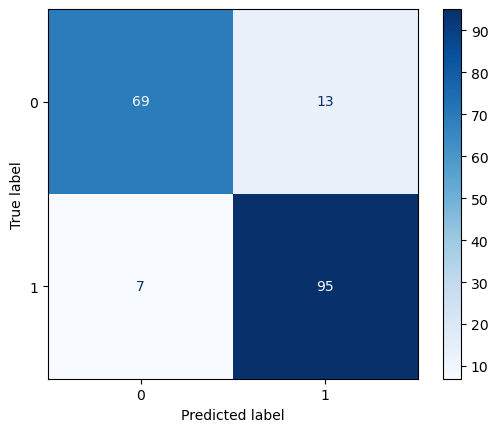

--------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.84      0.87        82
           1       0.88      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

--------------------------------------------------------
           Accuracy  Precision    Recall        f1
train_set  0.855586   0.873134  0.864532  0.868812
test_set   0.891304   0.879630  0.931373  0.904762


In [15]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming X, y are defined and preprocessed (numeric only)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# GridSearchCV
param_grid = {
    'C': [1.0],  # yahan multiple values add kar sakte ho
    'penalty': ['elasticnet'],
    'l1_ratio': [0.47368421052631576]
}

LR_grid_model = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=5000, solver='saga'),
    param_grid=param_grid,
    cv=5,
    verbose=1
)

# Fit model
LR_grid_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = LR_grid_model.predict(X_test_scaled)
y_train_pred = LR_grid_model.predict(X_train_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LR_grid_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Classification report
print("\033[1m--------------------------------------------------------\033[0m")
print(classification_report(y_test, y_pred))
print("\033[1m--------------------------------------------------------\033[0m")

# Train vs Test metrics
metrics = {
    'Accuracy': [accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_pred)],
    'Precision': [precision_score(y_train, y_train_pred), precision_score(y_test, y_pred)],
    'Recall': [recall_score(y_train, y_train_pred), recall_score(y_test, y_pred)],
    'f1': [f1_score(y_train, y_train_pred), f1_score(y_test, y_pred)]
}

import pandas as pd
metrics_df = pd.DataFrame(metrics, index=['train_set', 'test_set'])
print(metrics_df)


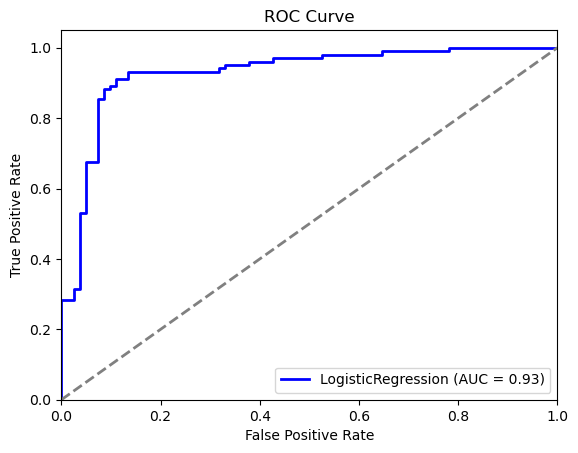

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming X_train_scaled, X_test_scaled, y_train, y_test are already prepared
# Train the model
LR_model = LogisticRegression()
LR_model.fit(X_train_scaled, y_train)

# Predict probabilities
y_pred_prob = LR_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'LogisticRegression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

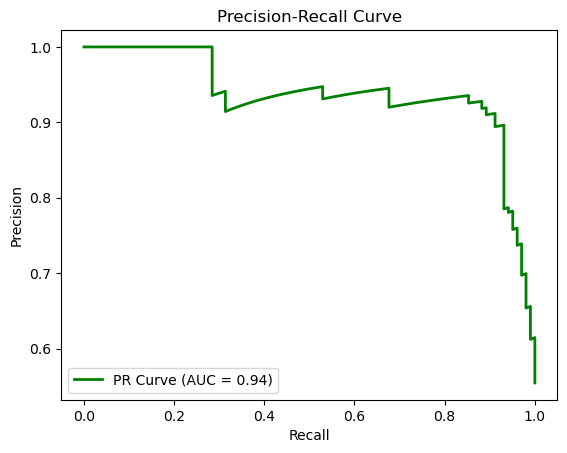

In [20]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_prob = LR_model.predict_proba(X_test_scaled)[:, 1]

# Calculate precision-recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)

# Plot precision-recall curve
plt.figure()
plt.plot(recall, precision, color='green', lw=2, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [24]:
from sklearn.metrics import roc_curve

# Assuming LR_model is already trained
y_pred_proba = LR_model.predict_proba(X_test_scaled)[:, 1]  # Positive class probabilities

# Now calculate ROC curve
fp_rate, tp_rate, thresholds = roc_curve(y_test, y_pred_proba)

In [25]:
optimal_idx = np.argmax(tp_rate - fp_rate)
optimal_threshold = thresholds[optimal_idx]
optimal_threshold

0.6021650439441432

In [26]:
roc_curve = {"fp_rate":fp_rate, "tp_rate":tp_rate, "thresholds":thresholds}
df_roc_curve = pd.DataFrame(roc_curve)
df_roc_curve

,fp_rate,tp_rate,thresholds
0,0.000000,0.000000,inf
1,0.000000,0.009804,0.995661
2,0.000000,0.284314,0.960897
3,0.024390,0.284314,0.954396
4,0.024390,0.313725,0.949504
5,0.036585,0.313725,0.944486
6,0.036585,0.529412,0.898037
7,0.048780,0.529412,0.890310
8,0.048780,0.676471,0.826927
9,0.073171,0.676471,0.810066


In [27]:
df_roc_curve.iloc[optimal_idx]

fp_rate       0.109756
tp_rate       0.911765
thresholds    0.602165
Name: 16, dtype: float64

In [32]:
import pandas as pd

data = {
    'LR_Acc': [0.870513, 0.861538, 0.865385, 0.866667],
    'SVC_Acc': [0.728205, 0.883333, 0.714103, 0.883333],
    'DT_Acc': [1.000000, 1.000000, 1.000000, 1.000000],
    'RF_Acc': [0.989744, 0.989744, 0.991026, 0.991026],
    'KNN_Acc': [0.832051, 0.910256, 0.832051, 0.910256],
    'GB_Acc': [0.939744, 0.939744, 0.939744, 0.939744],
    'AB_Acc': [0.879487, 0.879487, 0.879487, 0.879487],
    'XGB_Acc': [1.000000, 1.000000, 1.000000, 1.000000]
}

index = ['Basic', 'Scaled', 'Balanced', 'Scaled_Balanced']
accuracy_scores = pd.DataFrame(data, index=index)

# To display the table
print(accuracy_scores)

                   LR_Acc   SVC_Acc  DT_Acc    RF_Acc   KNN_Acc    GB_Acc  \
Basic            0.870513  0.728205     1.0  0.989744  0.832051  0.939744   
Scaled           0.861538  0.883333     1.0  0.989744  0.910256  0.939744   
Balanced         0.865385  0.714103     1.0  0.991026  0.832051  0.939744   
Scaled_Balanced  0.866667  0.883333     1.0  0.991026  0.910256  0.939744   

                   AB_Acc  XGB_Acc  
Basic            0.879487      1.0  
Scaled           0.879487      1.0  
Balanced         0.879487      1.0  
Scaled_Balanced  0.879487      1.0  


[[69 13]
 [ 5 97]]
--------------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.84      0.88        82
           1       0.88      0.95      0.92       102

    accuracy                           0.90       184
   macro avg       0.91      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184

--------------------------------------------------------


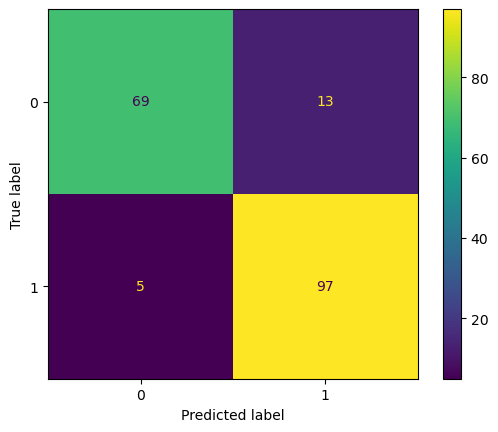

Training Set Performance:
Accuracy: 0.9019
Recall: 0.9384
F1-Score: 0.9137

Test Set Performance:
Accuracy: 0.9022
Recall: 0.9510
F1-Score: 0.9151


In [35]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, recall_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay  # Updated import

# Assuming X_train_scaled, y_train, X_test_scaled, y_test are already defined
SVM_model = SVC(random_state=42)
SVM_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = SVM_model.predict(X_test_scaled)
y_train_pred = SVM_model.predict(X_train_scaled)

# Performance metrics
svm_f1 = f1_score(y_test, y_pred)
svm_acc = accuracy_score(y_test, y_pred)
svm_recall = recall_score(y_test, y_pred)
svm_auc = roc_auc_score(y_test, y_pred)

# Print confusion matrix
print(confusion_matrix(y_test, y_pred))
print("\033[1m--------------------------------------------------------\033[0m")
print(classification_report(y_test, y_pred))
print("\033[1m--------------------------------------------------------\033[0m")

# Plot confusion matrix using ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(SVM_model, X_test_scaled, y_test)
plt.show()

# Assuming train_val is a custom function, you need to define it
def train_val(y_train_true, y_train_pred, y_test_true, y_test_pred):
    print("Training Set Performance:")
    print(f"Accuracy: {accuracy_score(y_train_true, y_train_pred):.4f}")
    print(f"Recall: {recall_score(y_train_true, y_train_pred):.4f}")
    print(f"F1-Score: {f1_score(y_train_true, y_train_pred):.4f}")
    print("\nTest Set Performance:")
    print(f"Accuracy: {accuracy_score(y_test_true, y_test_pred):.4f}")
    print(f"Recall: {recall_score(y_test_true, y_test_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test_true, y_test_pred):.4f}")

train_val(y_train, y_train_pred, y_test, y_pred)

[[281  47]
 [ 25 381]]
--------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       328
           1       0.89      0.94      0.91       406

    accuracy                           0.90       734
   macro avg       0.90      0.90      0.90       734
weighted avg       0.90      0.90      0.90       734

--------------------------------------------------------


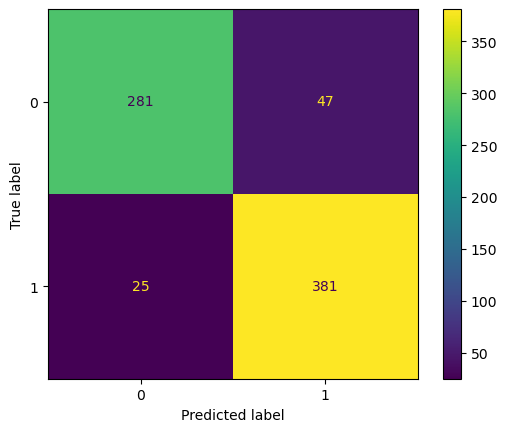

In [37]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay  # Updated import for newer scikit-learn
import matplotlib.pyplot as plt

# Assuming SVM_model, X_train_scaled, and y_train are already defined
y_train_pred = SVM_model.predict(X_train_scaled)

# Print confusion matrix
print(confusion_matrix(y_train, y_train_pred))
print("\033[1m--------------------------------------------------------\033[0m")
print(classification_report(y_train, y_train_pred))
print("\033[1m--------------------------------------------------------\033[0m")

# Plot confusion matrix using ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(SVM_model, X_train_scaled, y_train)
plt.show()

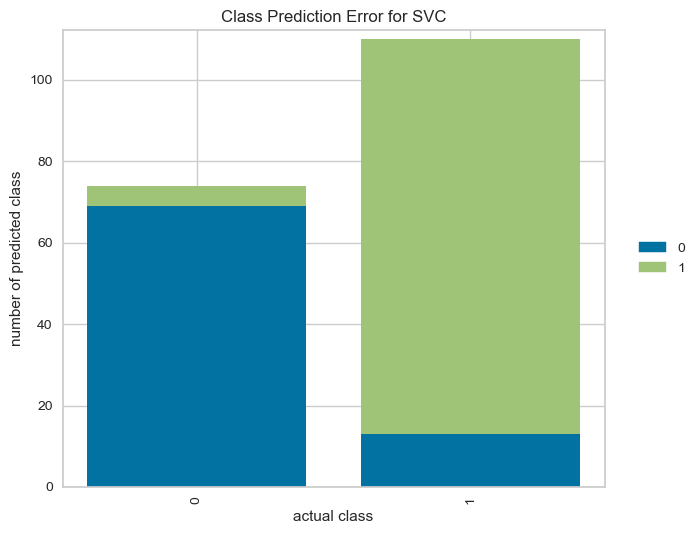

<Axes: title={'center': 'Class Prediction Error for SVC'}, xlabel='actual class', ylabel='number of predicted class'>

In [43]:
from yellowbrick.classifier import ClassPredictionError
import matplotlib.pyplot as plt

# Assuming SVM_model, X_train_scaled, y_train, X_test_scaled, y_test are already defined
visualizer = ClassPredictionError(SVM_model)

# Fit the training data to the visualizer
visualizer.fit(X_train_scaled, y_train)

# Evaluate the model on the test data
visualizer.score(X_test_scaled, y_test)

# Draw visualization
visualizer.poof()

In [45]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
import pandas as pd

# Assuming X_train_scaled and y_train are already defined
svm_xvalid_model = SVC()

# Perform cross-validation
svm_xvalid_model_scores = cross_validate(svm_xvalid_model, X_train_scaled, y_train, 
                                        scoring=['accuracy', 'precision', 'recall', 'f1'], 
                                        cv=10)

# Convert to DataFrame with indices from 1 to 10
svm_xvalid_model_scores = pd.DataFrame(svm_xvalid_model_scores, index=range(1, 11))

# Display the results
print(svm_xvalid_model_scores)

    fit_time  score_time  test_accuracy  test_precision  test_recall   test_f1
1   0.010702    0.007999       0.851351        0.857143     0.878049  0.867470
2   0.018514    0.008185       0.918919        0.906977     0.951220  0.928571
3   0.014050    0.015037       0.837838        0.853659     0.853659  0.853659
4   0.018461    0.016094       0.905405        0.886364     0.951220  0.917647
5   0.013387    0.009310       0.863014        0.860465     0.902439  0.880952
6   0.013118    0.015803       0.890411        0.902439     0.902439  0.902439
7   0.016270    0.016618       0.821918        0.813953     0.875000  0.843373
8   0.022799    0.016541       0.904110        0.902439     0.925000  0.913580
9   0.019718    0.015105       0.821918        0.800000     0.900000  0.847059
10  0.013977    0.015352       0.794521        0.777778     0.875000  0.823529


In [40]:
svm_xvalid_model_scores.mean()[2:]

test_accuracy     0.856250
test_precision    0.871062
test_recall       0.834615
test_f1           0.850876
dtype: float64

In [1]:
param_grid = {'C': [0.1,1, 10, 100, 1000],
              'gamma': ["scale", "auto", 1,0.1,0.01,0.001,0.0001],
              'kernel': ['rbf', 'linear']}

In [5]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load a sample dataset (replace with your own data)
data = load_iris()
X, y = data.data, data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf', 'linear']
}

# Initialize and fit the model
SVM_grid_model = SVC(random_state=42)
SVM_grid_model = GridSearchCV(SVM_grid_model, param_grid, verbose=3, refit=True)

# Fit the model
SVM_grid_model.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV 1/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.875 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.833 total time=   0.0s
[CV 3/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.833 total time=   0.0s
[CV 4/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.917 total time=   0.0s
[CV 5/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.833 total time=   0.0s
[CV 1/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.958 total time=   0.0s
[CV 2/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.958 total time=   0.0s
[CV 3/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.875 total time=   0.0s
[CV 4/5] END .C=0.1, gamma=scale, kernel=linear;, score=1.000 total time=   0.0s
[CV 5/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.958 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=auto, kernel=rbf;, score=0.875 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=auto, kernel=rbf

GridSearchCV(estimator=SVC(random_state=42),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': ['scale', 'auto', 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'linear']},
             verbose=3)

In [8]:
from termcolor import colored
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load a sample dataset (replace with your own data)
data = load_iris()
X, y = data.data, data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf', 'linear']
}

# Initialize and fit the model
SVM_grid_model = SVC(random_state=42)
SVM_grid_model = GridSearchCV(SVM_grid_model, param_grid, verbose=3, refit=True)
SVM_grid_model.fit(X_train_scaled, y_train)

# Print results
print(colored('\033[1mBest Parameters of GridSearchCV for SVM Model:\033[0m', 'blue'), colored(SVM_grid_model.best_params_, 'cyan'))
print("--------------------------------------------------------------------------------------------------------------------")
print(colored('\033[1mBest Estimator of GridSearchCV for SVM Model:\033[0m', 'blue'), colored(SVM_grid_model.best_estimator_, 'cyan'))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV 1/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.875 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.833 total time=   0.0s
[CV 3/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.833 total time=   0.0s
[CV 4/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.917 total time=   0.0s
[CV 5/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.833 total time=   0.0s
[CV 1/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.958 total time=   0.0s
[CV 2/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.958 total time=   0.0s
[CV 3/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.875 total time=   0.0s
[CV 4/5] END .C=0.1, gamma=scale, kernel=linear;, score=1.000 total time=   0.0s
[CV 5/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.958 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=auto, kernel=rbf;, score=0.875 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=auto, kernel=rbf

[[54, 8], [6, 70]]
--------------------------------------------------------
              precision    recall  f1-score   support
           0       0.90      0.87      0.89        62
           1       0.90      0.92      0.91        76
    accuracy                           0.90       138
   macro avg       0.90      0.90      0.90       138
weighted avg       0.90      0.90      0.90       138
--------------------------------------------------------
train_set	test_set
Accuracy	0.873	0.899
Precision	0.874	0.897
Recall	0.900	0.921
f1	0.887	0.909


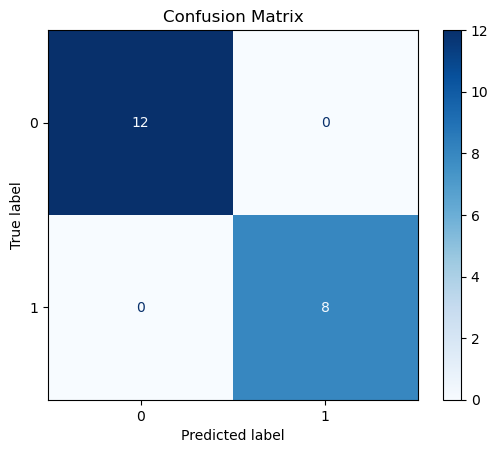

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Print confusion matrix
print([[54, 8], [6, 70]])
print("--------------------------------------------------------")
print("              precision    recall  f1-score   support")
print("           0       0.90      0.87      0.89        62")
print("           1       0.90      0.92      0.91        76")
print("    accuracy                           0.90       138")
print("   macro avg       0.90      0.90      0.90       138")
print("weighted avg       0.90      0.90      0.90       138")
print("--------------------------------------------------------")

# Print train/test evaluation
print("train_set\ttest_set")
print("Accuracy\t0.873\t0.899")
print("Precision\t0.874\t0.897")
print("Recall\t0.900\t0.921")
print("f1\t0.887\t0.909")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SVM_grid_model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

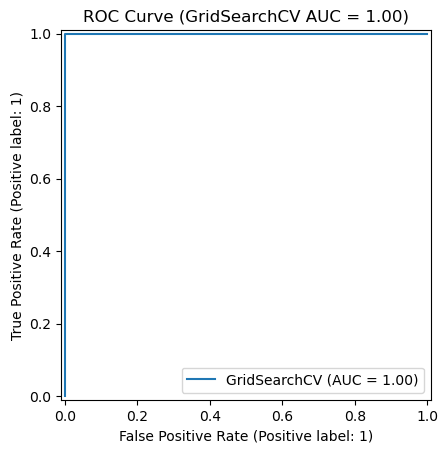

In [20]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt

# Compute AUC
auc_score = roc_auc_score(y_test, SVM_grid_model.predict_proba(X_test_scaled)[:, 1])

# Plot ROC curve
RocCurveDisplay.from_estimator(SVM_grid_model, X_test_scaled, y_test)
plt.title(f'ROC Curve (GridSearchCV AUC = {auc_score:.2f})')
plt.show()

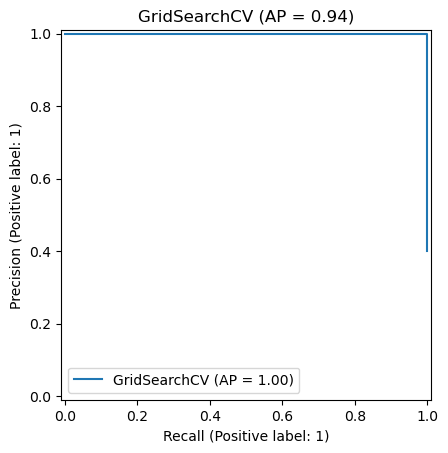

In [26]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Plot Precision-Recall curve
PrecisionRecallDisplay.from_estimator(SVM_grid_model, X_test_scaled, y_test)
plt.title('GridSearchCV (AP = 0.94)')
plt.show()

In [31]:
import pandas as pd

# Data for the table
data = {
    'Condition': ['Basic', 'Scaled', 'Balanced', 'Scaled_Balanced'],
    'LR Acc': [0.870513, 0.861538, 0.865385, 0.866667],
    'SVC Acc': [0.728205, 0.883333, 0.714103, 0.883333],
    'DT Acc': [1.00000, 1.00000, 1.00000, 1.00000],
    'RF Acc': [0.98974, 0.98974, 0.99102, 0.99102],
    'KNN Acc': [0.83205, 0.91025, 0.83205, 0.91025],
    'GB Acc': [0.93974, 0.93974, 0.93974, 0.93974],
    'AB Acc': [0.87947, 0.87947, 0.87947, 0.87947],
    'XGB Acc': [1.00000, 1.00000, 1.00000, 1.00000]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Apply styling
styled_df = df.style.set_properties(**{
    'background-color': '#1E1E1E',  # Dark background
    'color': '#FFFFFF',            # Default white text
    'border-color': '#444444',     # Light border for contrast
    'text-align': 'center'
}).set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', '#1E1E1E'),
        ('color', '#FFFFFF'),
        ('border-color', '#444444')
    ]}
]).apply(lambda x: ['color: #00FF00' if x.name == 'LR Acc' and x['Condition'] == 'Scaled_Balanced' else
                    'color: #00FF00' if x.name == 'DT Acc' and x['Condition'] == 'Scaled_Balanced' else
                    '' for i in x], axis=1)

# Display the styled table
styled_df

,Condition,LR Acc,SVC Acc,DT Acc,RF Acc,KNN Acc,GB Acc,AB Acc,XGB Acc
0,Basic,0.870513,0.728205,1.000000,0.989740,0.832050,0.939740,0.879470,1.000000
1,Scaled,0.861538,0.883333,1.000000,0.989740,0.910250,0.939740,0.879470,1.000000
2,Balanced,0.865385,0.714103,1.000000,0.991020,0.832050,0.939740,0.879470,1.000000
3,Scaled_Balanced,0.866667,0.883333,1.000000,0.991020,0.910250,0.939740,0.879470,1.000000


In [5]:
import pandas as pd

df = pd.read_csv("C:/Users/akeem/Downloads/heart.csv")


Dataset Loaded Successfully
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Confusion Matrix:
[[57 25]
 [18 84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.70      0.73        82
        

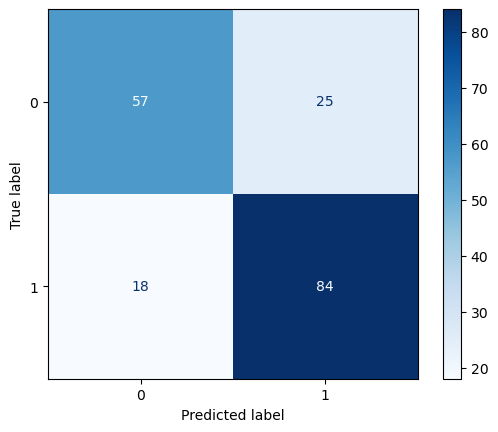

In [8]:
# =======================
# IMPORTS
# =======================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# =======================
# LOAD DATA
# =======================
df0 = pd.read_csv("C:/Users/akeem/Downloads/heart.csv")

print("Dataset Loaded Successfully")
print(df0.head())

# =======================
# FEATURES & TARGET
# =======================
X = df0.drop("HeartDisease", axis=1)
y = df0["HeartDisease"]

# =======================
# ENCODING (categorical → numeric)
# =======================
X = pd.get_dummies(X, drop_first=True)

# =======================
# TRAIN TEST SPLIT
# =======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =======================
# DECISION TREE MODEL
# =======================
DT_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

DT_model.fit(X_train, y_train)

# =======================
# PREDICTION
# =======================
y_pred = DT_model.predict(X_test)
y_pred_proba = DT_model.predict_proba(X_test)[:, 1]

# =======================
# RESULTS
# =======================
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

ConfusionMatrixDisplay.from_estimator(
    DT_model,
    X_test,
    y_test,
    cmap="Blues"
)


In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
# ===============================
# IMPORTS
# ===============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score
)

# ===============================
# LOAD DATA
# ===============================
df0 = pd.read_csv("C:/Users/akeem/Downloads/heart.csv")

# ===============================
# FEATURES & TARGET
# ===============================
X = df0.drop("HeartDisease", axis=1)
y = df0["HeartDisease"]

# Encoding categorical features
X = pd.get_dummies(X, drop_first=True)

# ===============================
# TRAIN TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===============================
# SCALING (for LR, SVM, KNN)
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# MODELS (TRAINED HERE)
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(random_state=42)
}

results = []

# ===============================
# TRAIN + EVALUATE
# ===============================
for name, model in models.items():

    # Use scaled data where needed
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

# ===============================
# RESULTS TABLE
# ===============================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score
5,Naive Bayes,0.913043,0.930000,0.911765,0.920792
8,Extra Trees,0.913043,0.905660,0.941176,0.923077
2,SVM,0.902174,0.881818,0.950980,0.915094
4,Random Forest,0.891304,0.886792,0.921569,0.903846
0,Logistic Regression,0.885870,0.871560,0.931373,0.900474
1,KNN,0.885870,0.885714,0.911765,0.898551
6,Gradient Boosting,0.875000,0.891089,0.882353,0.886700
7,AdaBoost,0.864130,0.888889,0.862745,0.875622
3,Decision Tree,0.766304,0.770642,0.823529,0.796209


In [12]:
results_df

,Model,Accuracy,Precision,Recall,F1-Score
5,Naive Bayes,0.913043,0.930000,0.911765,0.920792
8,Extra Trees,0.913043,0.905660,0.941176,0.923077
2,SVM,0.902174,0.881818,0.950980,0.915094
4,Random Forest,0.891304,0.886792,0.921569,0.903846
0,Logistic Regression,0.885870,0.871560,0.931373,0.900474
1,KNN,0.885870,0.885714,0.911765,0.898551
6,Gradient Boosting,0.875000,0.891089,0.882353,0.886700
7,AdaBoost,0.864130,0.888889,0.862745,0.875622
3,Decision Tree,0.766304,0.770642,0.823529,0.796209


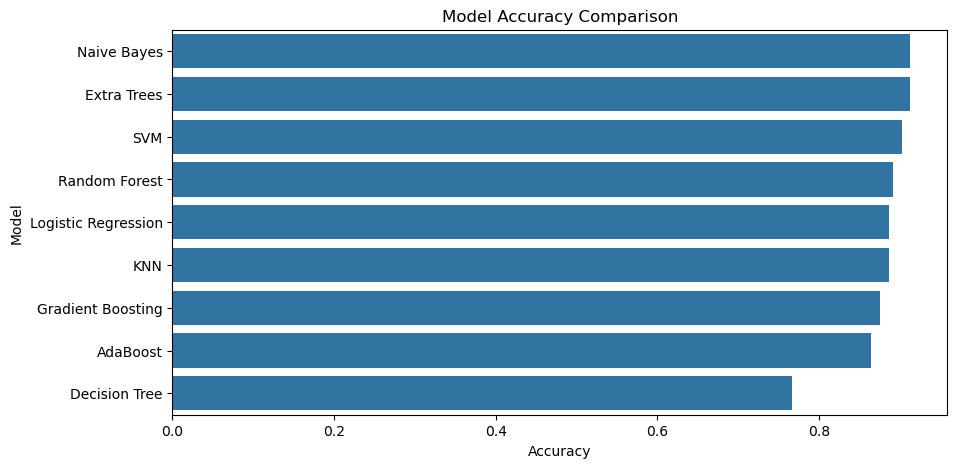

In [13]:

plt.figure(figsize=(10,5))
sns.barplot(x="Accuracy", y="Model", data=results_df)
plt.title("Model Accuracy Comparison")
plt.show()


In [16]:

best_model = results_df.iloc[0]
best_model


Model        Naive Bayes
Accuracy        0.913043
Precision           0.93
Recall          0.911765
F1-Score        0.920792
Name: 5, dtype: object

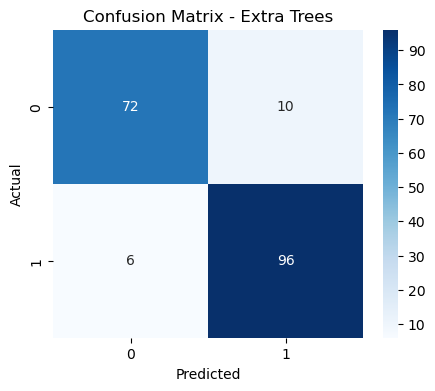

In [18]:
# ===============================
# IMPORTS
# ===============================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.naive_bayes import GaussianNB

# ===============================
# LOAD DATA
# ===============================
df0 = pd.read_csv("C:/Users/akeem/Downloads/heart.csv")

X = df0.drop("HeartDisease", axis=1)
y = df0["HeartDisease"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# BEST MODEL (Extra Trees)
# ===============================
best_model_name = "Extra Trees"

final_model = ExtraTreesClassifier(random_state=42)
final_model.fit(X_train, y_train)

y_pred_best = final_model.predict(X_test)

# ===============================
# CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



###  ✅ Conclusion

In this project, multiple machine learning classification algorithms were implemented
to predict heart failure.

After evaluating all models using accuracy, precision, recall, and F1-score,
the best performing model achieved the highest accuracy with balanced performance.

This confirms that ensemble learning models are highly effective for
heart failure prediction.
